In [ ]:
from google.colab import files
uploaded = files.upload()


Saving df_clean_K.xlsx to df_clean_K.xlsx


In [ ]:
import subprocess, sys
def _pip(p): subprocess.check_call([sys.executable,"-m","pip","install","-q",p])

import pandas as pd, numpy as np, json, warnings, math, time, os, copy, joblib, shutil
from datetime import datetime
warnings.filterwarnings('ignore')

try: import numpy_financial as npf
except: _pip("numpy_financial"); import numpy_financial as npf

from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                               IsolationForest, GradientBoostingRegressor)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, mean_absolute_error,
                              mean_squared_error, r2_score,
                              classification_report, roc_auc_score)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import kneighbors_graph
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
import xgboost as xgb

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except: _pip("optuna"); import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# LLM
_HAS_LLM = False; _llm_client = None; _LLM_MODEL = "hosted_vllm/Llama-3.1-70B-Instruct"
try:
    from openai import OpenAI as _OpenAI
    _llm_client = _OpenAI(api_key="sk-e8d1f52f7bce4a349af80b4080b24205",
                           base_url="https://tokenfactory.esprit.tn/api")
    _HAS_LLM = True; print("LLM configured.")
except Exception as e: print(f"LLM not configured: {e}")

np.random.seed(42)
print("Imports complete.")


LLM configured.
Imports complete.


In [ ]:
F = "df_clean_K.xlsx"
if os.path.exists(F):
    df_modeling = pd.read_excel(F)
else:
    for alt in ["processed_real_estate_dataset.parquet","processed_real_estate_dataset.csv"]:
        if os.path.exists(alt):
            df_modeling = pd.read_parquet(alt) if alt.endswith(".parquet") else pd.read_csv(alt)
            break
    else:
        raise FileNotFoundError("Upload df_modeling_with_locations.parquet")
    for c in ["lat","lon","n_hospitals","n_schools","n_transit","n_retail",
              "n_industrial","dist_hospital_km","dist_transit_km",
              "elevation_m","landslide_score","osm_confidence","is_urban"]:
        if c not in df_modeling.columns: df_modeling[c] = None

print(f"Shape: {df_modeling.shape}")
print(df_modeling["Type"].value_counts())
print(f"\nGeocoded: {df_modeling['lat'].notna().sum()}/{len(df_modeling)}")


Shape: (26599, 36)
Type
Appartement a louer                            5190
Appartement a vendre                           4420
Maison a vendre                                3574
appartements                                   3157
Terrain a vendre                               3113
Maison a louer                                 1930
maisons-et-villas                              1391
Local a vendre                                  928
Local a louer                                   884
bureaux-et-plateaux                             881
terrains-et-fermes                              592
magasins%2c-commerces-et-locaux-industriels     539
Name: count, dtype: int64

Geocoded: 11789/26599


## Stage 1/4 — Geocoding

In [ ]:
# Skip if checkpoint exists
if os.path.exists("_ckpt1_geocoded.parquet"):
    df = pd.read_parquet("_ckpt1_geocoded.parquet")
    print(f"Resumed from checkpoint: {df['lat'].notna().sum()} geocoded rows.")
else:
    geolocator  = Nominatim(user_agent="kadastra_etl_colab_2025", timeout=10)
    _geocode_rl = RateLimiter(geolocator.geocode, min_delay_seconds=1.1,
                               error_wait_seconds=5, return_value_on_exception=None)
    TN_LAT, TN_LON = (30.2, 37.6), (7.5, 11.6)

    def _valid(la, lo):
        return TN_LAT[0]<=la<=TN_LAT[1] and TN_LON[0]<=lo<=TN_LON[1]

    _cache = {}
    def _geo(addr):
        if pd.isna(addr) or str(addr).strip()=="": return None, None
        k = str(addr).strip()
        if k in _cache: return _cache[k]
        for q in [f"{k}, Tunisia", f"{k.split(',')[0].strip()}, Tunisia"]:
            try:
                loc = _geocode_rl(q)
                if loc and _valid(loc.latitude, loc.longitude):
                    _cache[k] = (loc.latitude, loc.longitude)
                    return _cache[k]
            except: pass
        _cache[k] = (None, None)
        return None, None

    addrs = df["Adresse"].dropna().unique().tolist()
    print(f"Geocoding {len(addrs)} unique addresses (~{len(addrs)*1.1/60:.0f} min)...")
    for a in tqdm(addrs, desc="Geocoding"):
        _geo(a)

    df["lat"] = df["Adresse"].map(lambda a: _cache.get(str(a).strip(),(None,None))[0])
    df["lon"] = df["Adresse"].map(lambda a: _cache.get(str(a).strip(),(None,None))[1])

    if "geo_coords" in df.columns:
        valid_gc = df["geo_coords"].notna() & df["geo_coords"].astype(str).str.strip().ne("")
        for idx in df.index[valid_gc]:
            try:
                parts = str(df.at[idx,"geo_coords"]).replace("(","").replace(")","").split(",")
                la, lo = float(parts[0]), float(parts[1])
                if _valid(la, lo):
                    df.at[idx,"lat"], df.at[idx,"lon"] = la, lo
            except: pass

    n = df["lat"].notna().sum()
    print(f"Done: {n}/{len(df)} geocoded ({n/len(df)*100:.1f}%)")

    df.to_parquet("_ckpt1_geocoded.parquet", index=False)
    files.download("_ckpt1_geocoded.parquet")
    print("Checkpoint saved + downloaded.")


Geocoding 680 unique addresses (~12 min)...


Geocoding:   0%|          | 0/680 [00:00<?, ?it/s]

Done: 13855/28770 geocoded (48.2%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Checkpoint saved + downloaded.


## Stage 2/4 — OSM POI Features

In [ ]:
if os.path.exists("_ckpt2_osm.parquet"):
    df = pd.read_parquet("_ckpt2_osm.parquet")
    print(f"Resumed from OSM checkpoint.")
else:
    if "lat" not in df.columns:
        df = pd.read_parquet("_ckpt1_geocoded.parquet")

    GRID, RADIUS = 0.02, 1000
    TAGS = {
        "hospitals": {"amenity":["hospital","clinic","doctors"]},
        "schools":   {"amenity":["school","university","college","kindergarten"]},
        "transit":   {"public_transport":True,"railway":["station","halt"],"amenity":["bus_station"]},
        "retail":    {"landuse":"retail","shop":True},
        "industrial":{"landuse":"industrial"},
    }
    NULL = dict(n_hospitals=0,n_schools=0,n_transit=0,n_retail=0,n_industrial=0,
                dist_hospital_km=None,dist_transit_km=None,osm_confidence=0.0,is_urban=0)

    _oc = {}
    def _ck(la,lo): return (round(la/GRID)*GRID, round(lo/GRID)*GRID)

    def _qosm(la,lo):
        k = _ck(la,lo)
        if k in _oc: return _oc[k]
        counts,dists,tot = {},{},0
        for name,tags in TAGS.items():
            try:
                gdf = ox.features_from_point((la,lo), tags=tags, dist=RADIUS)
                n = len(gdf)
                counts[f"n_{name}"] = n; tot += n
                if name in ("hospitals","transit") and n>0:
                    cents = gdf.geometry.centroid
                    md = min(math.sqrt((la-c.y)**2+(lo-c.x)**2)*111 for c in cents)
                    col = "dist_hospital_km" if name=="hospitals" else "dist_transit_km"
                    dists[col] = round(md,2)
            except: counts[f"n_{name}"] = 0
        try:
            ub = ox.features_from_point((la,lo), tags={"building":True}, dist=500)
            iu = 1 if len(ub)>20 else 0
        except: iu = 0
        r = {**NULL,**counts,**dists,"osm_confidence":round(min(tot/50,1.0),2),"is_urban":iu}
        _oc[k] = r
        return r

    hc = df[df["lat"].notna() & df["lon"].notna()].copy()
    hc["_ckla"] = (hc["lat"]/GRID).round()*GRID
    hc["_cklo"] = (hc["lon"]/GRID).round()*GRID
    ukeys = list(set(zip(hc["_ckla"],hc["_cklo"])))
    n = len(ukeys)
    MW = 8
    print(f"OSM: {n} grid cells, {MW} workers (~{n*5/MW/60:.0f} min est.)")

    t0 = time.time()
    done = [0]
    def _w(k):
        la,lo = k
        return k, _qosm(la,lo)

    with ThreadPoolExecutor(max_workers=MW) as ex:
        futs = {ex.submit(_w,k):k for k in ukeys}
        with tqdm(total=n, desc="OSM", unit="cell") as pb:
            for f in as_completed(futs):
                try:
                    k,r = f.result(timeout=30)
                    _oc[k] = r
                except:
                    k = futs[f]; _oc[k] = dict(NULL)
                pb.update(1)
                done[0] += 1
                if done[0] % 50 == 0:
                    el = time.time()-t0
                    rt = done[0]/el
                    rm = (n-done[0])/rt if rt>0 else 0
                    print(f"  [{done[0]}/{n}] {el/60:.1f}min elapsed  ETA {rm/60:.1f}min")

    la_arr = df["lat"].to_numpy()
    lo_arr = df["lon"].to_numpy()
    ckla = np.round(np.array(la_arr,dtype=float)/GRID)*GRID
    cklo = np.round(np.array(lo_arr,dtype=float)/GRID)*GRID
    rows = []
    for i in range(len(df)):
        la = la_arr[i]
        if isinstance(la,float) and np.isnan(la):
            rows.append(NULL)
        else:
            rows.append(_oc.get((float(ckla[i]),float(cklo[i])),NULL))
    odf = pd.DataFrame(rows, index=df.index)
    df = pd.concat([df, odf], axis=1)
    print(f"OSM done in {(time.time()-t0)/60:.1f} min.")

    df.to_parquet("_ckpt2_osm.parquet", index=False)
    files.download("_ckpt2_osm.parquet")
    print("Checkpoint saved + downloaded.")


OSM: 203 grid cells, 8 workers (~2 min est.)


OSM:   0%|          | 0/203 [00:00<?, ?cell/s]

  [50/203] 103.6min elapsed  ETA 317.0min
  [100/203] 241.4min elapsed  ETA 248.7min
  [150/203] 404.3min elapsed  ETA 142.9min
  [200/203] 429.6min elapsed  ETA 6.4min
OSM done in 430.1 min.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Checkpoint saved + downloaded.


## Stage 3/4 — Elevation

In [ ]:
if os.path.exists("_ckpt3_elev.parquet"):
    df = pd.read_parquet("_ckpt3_elev.parquet")
    print("Resumed from elevation checkpoint.")
else:
    if "n_hospitals" not in df.columns:
        df = pd.read_parquet("_ckpt2_osm.parquet")

    URL = "https://api.open-elevation.com/api/v1/lookup"
    CHUNK, TOUT = 100, 20
    lats, lons = df["lat"].tolist(), df["lon"].tolist()
    elevs = [None]*len(df)
    valid = [(i,lats[i],lons[i]) for i in range(len(df))
             if lats[i] is not None and not(isinstance(lats[i],float) and math.isnan(lats[i]))]

    print(f"Elevation: {len(valid)} pts, chunks of {CHUNK}...")
    for cs in tqdm(range(0,len(valid),CHUNK), desc="Elevation"):
        chunk = valid[cs:cs+CHUNK]
        try:
            resp = _req.post(URL, json={"locations":[{"latitude":la,"longitude":lo}
                                                      for _,la,lo in chunk]}, timeout=TOUT)
            if resp.status_code == 200:
                res = resp.json().get("results",[])
                for j,(i,_,_) in enumerate(chunk):
                    if j<len(res): elevs[i] = res[j].get("elevation")
        except: pass

    df["elevation_m"] = elevs
    ne = sum(1 for e in elevs if e is not None)
    print(f"Elevation: {ne}/{len(valid)} resolved.")

    df.to_parquet("_ckpt3_elev.parquet", index=False)
    files.download("_ckpt3_elev.parquet")
    print("Checkpoint saved + downloaded.")


Elevation: 13855 pts, chunks of 100...


Elevation:   0%|          | 0/139 [00:00<?, ?it/s]

Elevation: 13855/13855 resolved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Checkpoint saved + downloaded.


## Stage 4/4 — Landslide Hazard

In [ ]:
if "elevation_m" not in df.columns:
    df = pd.read_parquet("_ckpt3_elev.parquet")

LP = "gdlnd.asc"
if not os.path.exists(LP):
    print(f"{LP} not found — upload gdlnd.asc + gdlnd.prj")
    df["landslide_score"] = None
else:
    ds = rasterio.open(LP)
    print(f"Raster: {ds.width}x{ds.height}")
    lats, lons = df["lat"].tolist(), df["lon"].tolist()
    coords, vidx = [], []
    for i in range(len(df)):
        la,lo = lats[i],lons[i]
        if la is not None and lo is not None and not(isinstance(la,float) and math.isnan(la)):
            coords.append((lo,la)); vidx.append(i)
    scores = [None]*len(df)
    if coords:
        try:
            samples = list(ds.sample(coords))
            for j,i in enumerate(vidx):
                v = float(samples[j][0])
                scores[i] = round(v,1) if v>=0 else None
        except Exception as e:
            print(f"Sampling error: {e}")
    ds.close()
    df["landslide_score"] = scores
    nl = sum(1 for s in scores if s is not None)
    print(f"Landslide: {nl}/{len(vidx)} resolved.")


Raster: 8640x3432
Landslide: 0/13855 resolved.


In [ ]:
# Drop noisy Tayara URL-encoded types — incompatible price distributions
TAYARA_TYPES = [
    "appartements", "maisons-et-villas", "terrains-et-fermes",
    "bureaux-et-plateaux", "magasins%2c-commerces-et-locaux-industriels",
]

before = len(df_modeling)
df_modeling = df_modeling[~df_modeling["Type"].isin(TAYARA_TYPES)].reset_index(drop=True)
after = len(df_modeling)
print(f"Dropped {before - after} Tayara rows ({before}→{after})")
print(df_modeling["Type"].value_counts())

df_modeling["_is_sale"] = df_modeling["Type"].str.contains("vendre", case=False, na=False)
print(f"\nSale: {df_modeling['_is_sale'].sum():,}  |  Rental: {(~df_modeling['_is_sale']).sum():,}")

Dropped 6560 Tayara rows (26599→20039)
Type
Appartement a louer     5190
Appartement a vendre    4420
Maison a vendre         3574
Terrain a vendre        3113
Maison a louer          1930
Local a vendre           928
Local a louer            884
Name: count, dtype: int64

Sale: 12,035  |  Rental: 8,004


In [ ]:
_BASELINE = {
    "reg_new_promoter":[(200_000,0.01),(500_000,0.02),(float("inf"),0.03)],
    "cpf_rate":0.01,"reg_resale_low":0.06,"reg_resale_high":0.10,
    "reg_resale_thresh":1_000_000,"notary_rate":0.015,"deed_stamp_per_page":30,
    "tib_rate":0.015,"undeveloped_land":0.003,"ifi_rate":0.005,
    "ifi_threshold":3_000_000,"tcl_rate":0.002,
    "irpp_rental_flat":0.20,"irpp_nonresident":0.15,
    "cgt_lt10":0.10,"cgt_ge10":0.05,"cgt_index_per_year":0.10,"cgt_withholding":0.025,
    "bcт_tmm":0.0749,"mortgage_rate_mid":0.09,"mortgage_max_years":25,"ltv_max":0.70,
    "gross_yield_national":0.0543,"gross_yield_tunis":0.0725,"gross_yield_sfax":0.054,
    "appreciation_national":0.050,"appreciation_tunis":0.068,
    "appreciation_sousse":0.075,"appreciation_sfax":0.055,"appreciation_nabeul":0.065,
    "inflation_cpi":0.049,"vat_residential_new":0.13,
}
TUNISIA_CONSTANTS = copy.deepcopy(_BASELINE)
def rollback_constants():
    global TUNISIA_CONSTANTS
    TUNISIA_CONSTANTS = copy.deepcopy(_BASELINE)
    print("Rolled back to baseline.")

C = TUNISIA_CONSTANTS
print(f"Constants loaded. BCT={C['bcт_tmm']*100:.2f}% Mortgage={C['mortgage_rate_mid']*100:.0f}%")


Constants loaded. BCT=7.49% Mortgage=9%


## Data Sources
- **Property listings:** Mubawab & Tayara (scraped)
- **Geocoding:** OpenStreetMap / Nominatim API
- **POI features:** Overpass API (hospitals, schools, transit, retail, industrial within 1km)
- **Elevation:** SRTM3 via open-elevation.com REST API
- **Landslide hazard:** NASA SEDAC (gdlnd.asc)
- **Tax rates:** Ministère des Finances TN, Code IRPP-IS 2024, Loi de Finances 2025
- **BCT rate:** Banque Centrale de Tunisie (TMM = 7.49%, Sept 2025)
- **Market benchmarks:** GlobalPropertyGuide Q2 2025


# C1 — INVESTMENT SCENARIO SIMULATOR
**Model A:** XGBoost regressor (one per property type) — price prediction

**Model B:** Monte Carlo NPV (10k paths, stochastic appreciation + yield + vacancy)

**Hyperparameter tuning:** Optuna on XGBoost (n_estimators, max_depth, learning_rate, subsample, colsample_bytree)

In [ ]:
class InvestmentScenarioSimulator:
    FEAT_COLS = ['surface_numeric','pieces','chambres','sallesdebain',
                 'meuble','neuf','parking','ascenseur','balcon_terrasse',
                 'climatisation','chauffage','jardin','piscine']

    def __init__(self, df, tune=True):
        self.df = df; self.C = TUNISIA_CONSTANTS
        self._xgb_models = {}; self._xgb_trained = False
        self._metrics_table = []
        self._train_xgb(tune=tune)

    def _train_xgb(self, tune=True):
        for pt, grp in self.df.groupby("Type"):
            grp = grp.dropna(subset=["price_numeric"])
            if len(grp) < 50: continue
            avail = [c for c in self.FEAT_COLS if c in grp.columns]
            X = grp[avail].astype(float).fillna(grp[avail].astype(float).median())
            y = grp["price_numeric"].astype(float)
            X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

            if tune:
                def obj(trial):
                    p = {
                        "n_estimators": trial.suggest_int("n_estimators",100,500),
                        "max_depth": trial.suggest_int("max_depth",3,8),
                        "learning_rate": trial.suggest_float("lr",0.01,0.2,log=True),
                        "subsample": trial.suggest_float("sub",0.6,1.0),
                        "colsample_bytree": trial.suggest_float("col",0.5,1.0),
                    }
                    m = xgb.XGBRegressor(**p, random_state=42, verbosity=0)
                    m.fit(X_tr, y_tr, eval_set=[(X_te,y_te)], verbose=False)
                    return mean_absolute_error(y_te, m.predict(X_te))

                study = optuna.create_study(direction="minimize",
                                            sampler=optuna.samplers.TPESampler(seed=42))
                study.optimize(obj, n_trials=50, show_progress_bar=False)
                best_p = study.best_params
                best_p["n_estimators"] = best_p.pop("n_estimators")
                best_p["learning_rate"] = best_p.pop("lr")
                best_p["subsample"] = best_p.pop("sub")
                best_p["colsample_bytree"] = best_p.pop("col")
            else:
                best_p = {"n_estimators":300,"max_depth":5,"learning_rate":0.05,
                           "subsample":0.8,"colsample_bytree":0.8}

            model = xgb.XGBRegressor(**best_p, random_state=42, verbosity=0)
            model.fit(X_tr, y_tr, eval_set=[(X_te,y_te)], verbose=False)
            pred = model.predict(X_te)
            mae  = float(mean_absolute_error(y_te, pred))
            rmse = float(np.sqrt(mean_squared_error(y_te, pred)))
            r2   = float(r2_score(y_te, pred))
            cv   = cross_val_score(model, X, y, cv=5, scoring="neg_mean_absolute_error")
            cv_mae = float(-cv.mean())

            self._xgb_models[pt] = {"model":model,"features":avail,
                                     "mae":mae,"rmse":rmse,"r2":r2,
                                     "cv_mae":cv_mae,"params":best_p,"n_train":len(X_tr)}
            self._metrics_table.append({
                "Type":pt,"N_train":len(X_tr),"N_test":len(X_te),
                "MAE":f"{mae:,.0f}","RMSE":f"{rmse:,.0f}","R²":f"{r2:.3f}",
                "CV_MAE_5fold":f"{cv_mae:,.0f}",
                "best_n_est":best_p.get("n_estimators"),
                "best_depth":best_p.get("max_depth"),
                "best_lr":f"{best_p.get('learning_rate',0):.3f}",
            })

        self._xgb_trained = bool(self._xgb_models)
        if self._xgb_trained:
            print(f"C1: XGBoost trained for {len(self._xgb_models)} types (Optuna-tuned={tune})")

    def show_metrics(self):
        df_m = pd.DataFrame(self._metrics_table)
        print("\n" + "="*80)
        print("C1 XGBoost — Model Performance per Property Type")
        print("="*80)
        print(df_m.to_string(index=False))
        print("\nInterpretation:")
        print("  • MAE = average absolute error in TND on held-out test set")
        print("  • R² > 0.7 = strong predictive power; < 0.3 = weak")
        print("  • CV_MAE confirms stability across 5 folds (not overfit if close to test MAE)")
        print("  • Optuna tuned n_estimators, max_depth, lr, subsample, colsample_bytree")
        return df_m

    def predict_exit_price(self, prop, years):
        pt = prop.get("Type","")
        rate = self._appr(prop.get("Adresse",""))
        if pt not in self._xgb_models:
            return float(prop["price_numeric"])*(1+rate)**years
        info = self._xgb_models[pt]
        row = {c:float(prop.get(c,0) or 0) for c in info["features"]}
        base = float(info["model"].predict(pd.DataFrame([row]))[0])
        return base*(1+rate)**years

    def monte_carlo_npv(self, prop, years=5, n_sims=10_000, scenario="rental"):
        C=self.C; price=float(prop["price_numeric"]); down=price*(1-C["ltv_max"])
        mortg=price-down; mr=C["mortgage_rate_mid"]/12; nmo=C["mortgage_max_years"]*12
        mp=npf.pmt(mr,nmo,-mortg) if mortg>0 else 0.0; disc=C["bcт_tmm"]
        rng=np.random.default_rng(42)
        appr=rng.normal(self._appr(prop.get("Adresse","")),0.02,(n_sims,years))
        gy=rng.normal(self._yld(prop.get("Adresse","")),0.015,n_sims).clip(0.01,0.15)
        vac=rng.beta(2,8,(n_sims,years))
        npvs=np.empty(n_sims)
        for s in range(n_sims):
            cf=[-down]; cur=price
            for yr in range(years):
                cur*=(1+appr[s,yr]); gr=cur*gy[s]
                nr=gr*(1-vac[s,yr])*(1-C["irpp_rental_flat"])
                cf.append((nr-cur*0.01-mp*12) if scenario=="rental" else -(cur*0.01+mp*12))
            if scenario=="flip":
                gain=max(0,cur-price*(1+C["cgt_index_per_year"])**years)
                cgt=gain*(C["cgt_ge10"] if years>=10 else C["cgt_lt10"])
                rem=abs(npf.pv(mr,nmo-years*12,mp)); cf[-1]+=cur-rem-cgt
            npvs[s]=npf.npv(disc,cf)
        return {"npv_p5":float(np.percentile(npvs,5)),"npv_p50":float(np.percentile(npvs,50)),
                "npv_p95":float(np.percentile(npvs,95)),"prob_positive":float(np.mean(npvs>0)),
                "n_sims":n_sims}

    def calculate_rental_yield(self, prop):
        C=self.C; price=float(prop.get("price_numeric",0) or 0)
        if price<=0: return {"gross_yield":0,"net_yield":0,"estimated_monthly_rent":0,
                             "gross_annual_rent":0,"net_annual_rent":0,"annual_expenses":0}
        gr=self._yld(prop.get("Adresse",""))
        ga=price*gr; irpp=ga*C["irpp_rental_flat"]; maint=price*0.01; ins=300; mgmt=ga*0.10
        ext=(1000 if prop.get("piscine",0)==1 else 0)+(500 if prop.get("jardin",0)==1 else 0)
        exp=irpp+maint+ins+mgmt+ext; na=ga-exp
        return {"estimated_monthly_rent":round(ga/12),"gross_annual_rent":round(ga),
                "net_annual_rent":round(na),"annual_expenses":round(exp),
                "gross_yield":round(gr*100,2),"net_yield":round(na/price*100,2)}

    def calculate_roi(self, prop, years=5, scenario="rental"):
        C=self.C; price=float(prop.get("price_numeric",0) or 0)
        down=price*(1-C["ltv_max"]); mortg=price-down
        mr=C["mortgage_rate_mid"]/12; nmo=C["mortgage_max_years"]*12
        mp=npf.pmt(mr,nmo,-mortg) if mortg>0 else 0.0
        rental=self.calculate_rental_yield(prop)
        ap=self._appr(prop.get("Adresse",""))
        cfs=[-down]; cur=price
        for _ in range(years):
            cur*=(1+ap)
            cfs.append((rental["net_annual_rent"]-mp*12) if scenario=="rental" else -(mp*12))
        if scenario=="flip":
            gain=max(0,cur-price*(1+C["cgt_index_per_year"])**years)
            cgt=gain*(C["cgt_ge10"] if years>=10 else C["cgt_lt10"])
            rem=abs(npf.pv(mr,nmo-years*12,mp)); cfs[-1]+=cur-rem-cgt
        try: irr=float(npf.irr(cfs))*100; irr=irr if np.isfinite(irr) else 0.0
        except: irr=0.0
        npv_val=float(npf.npv(C["bcт_tmm"],cfs))
        cumul=np.cumsum(cfs); pb=next((i for i,v in enumerate(cumul) if v>=0),years)
        return {"initial_investment":round(down),"monthly_mortgage":round(mp,2),
                "irr_percent":round(irr,2),"npv_tnd":round(npv_val),
                "payback_years":pb,"cash_flows":[round(c) for c in cfs]}

    def _appr(self, loc):
        C=self.C; l=str(loc).lower()
        if "tunis" in l: return C["appreciation_tunis"]
        if "sousse" in l: return C["appreciation_sousse"]
        if "sfax" in l: return C["appreciation_sfax"]
        if "nabeul" in l or "hammamet" in l: return C["appreciation_nabeul"]
        return C["appreciation_national"]

    def _yld(self, loc):
        C=self.C; l=str(loc).lower()
        if "tunis" in l: return C["gross_yield_tunis"]
        if "sfax" in l: return C["gross_yield_sfax"]
        return C["gross_yield_national"]

# ── Train ─────────────────────────────────────────────────────────────────
print("Training C1 (Optuna-tuned XGBoost)... ~2-5 min")
t0 = time.time()
simulator = InvestmentScenarioSimulator(df_modeling, tune=True)
c1_metrics = simulator.show_metrics()
print(f"\nC1 training time: {(time.time()-t0)/60:.1f} min")


Training C1 (Optuna-tuned XGBoost)... ~2-5 min
C1: XGBoost trained for 7 types (Optuna-tuned=True)

C1 XGBoost — Model Performance per Property Type
                Type  N_train  N_test       MAE       RMSE     R² CV_MAE_5fold  best_n_est  best_depth best_lr
 Appartement a louer     4152    1038       499        668  0.550          543         274           8   0.018
Appartement a vendre     3536     884    93,140    132,401  0.584       94,188         401           6   0.019
       Local a louer      656     164     4,330     11,075 -0.445        5,726         292           6   0.010
      Local a vendre      581     146 1,694,845 10,221,944 -0.141    6,755,992         459           6   0.017
      Maison a louer     1544     386     1,131      1,450  0.480        1,141         224           4   0.041
     Maison a vendre     2859     715   295,230    421,031  0.460      314,491         497           6   0.024
    Terrain a vendre     1885     472 2,773,697 22,850,147 -0.014  199,045

# C2 — TAX ADVANTAGE OPTIMIZER
**Model A:** Deterministic rule engine (exact Tunisian tax law — no approximation)

**Model B:** Optuna TPE search over (holding_years, LTV, scenario, structure) → max after-tax IRR

No ML model to tune here — the rule engine is analytically exact. Optuna finds the optimal investment structure.

In [ ]:
class TaxAdvantageOptimizer:
    def __init__(self): self.C = TUNISIA_CONSTANTS

    def compute_acquisition_costs(self, price, is_new=False):
        C=self.C; cpf=price*C["cpf_rate"]; notary=price*C["notary_rate"]
        if is_new:
            reg=0
            for lim,rate in C["reg_new_promoter"]:
                if price<=lim: reg=price*rate; break
        else:
            rate=C["reg_resale_low"] if price<=C["reg_resale_thresh"] else C["reg_resale_high"]
            reg=price*rate
        tf=reg+cpf+notary
        return {"price":round(price),"registration":round(reg),"cpf":round(cpf),
                "notary":round(notary),"total_fees":round(tf),
                "total_cost":round(price+tf),"fees_pct":round(tf/price*100,2)}

    def compute_annual_taxes(self, dv, is_comm=False, patrimony=0, turnover=0):
        C=self.C; tib=dv*C["tib_rate"]
        tcl=turnover*C["tcl_rate"] if is_comm else 0
        ifi=dv*C["ifi_rate"] if patrimony>=C["ifi_threshold"] else 0
        return {"tib":round(tib),"tcl":round(tcl),"ifi":round(ifi),"total":round(tib+tcl+ifi)}

    def compute_capital_gains_tax(self, buy, sell, yrs):
        C=self.C; idx=buy*(1+C["cgt_index_per_year"])**yrs
        gain=max(0,sell-idx); rate=C["cgt_ge10"] if yrs>=10 else C["cgt_lt10"]
        cgt=gain*rate; wh=sell*C["cgt_withholding"]
        return {"sale_price":round(sell),"indexed_cost":round(idx),"taxable_gain":round(gain),
                "cgt_rate":rate,"cgt":round(cgt),"withholding":round(wh),
                "net_proceeds":round(sell-cgt)}

    def compute_rental_tax(self, gross):
        C=self.C; tax=gross*C["irpp_rental_flat"]
        return {"gross_rent":round(gross),"irpp":round(tax),"net_rent":round(gross-tax)}

    def sweep_holding_period(self, prop, profile):
        price=float(prop["price_numeric"]); ap=self.C["appreciation_national"]
        gr=self.C["gross_yield_national"]; is_new=profile.get("is_new_promoter",False)
        acq=self.compute_acquisition_costs(price,is_new); results=[]
        for yr in range(1,16):
            sale=price*(1+ap)**yr; cgt=self.compute_capital_gains_tax(price,sale,yr)
            rt=self.compute_rental_tax(price*gr); at=self.compute_annual_taxes(price)
            cfs=[-acq["total_cost"]]+[rt["net_rent"]-at["total"]]*yr
            cfs[-1]+=cgt["net_proceeds"]
            try: irr=float(npf.irr(cfs))*100; irr=irr if np.isfinite(irr) else 0
            except: irr=0
            results.append({"years":yr,"irr_pct":round(irr,2),"net_proceeds":cgt["net_proceeds"],
                             "cgt":cgt["cgt"],"cgt_rate":cgt["cgt_rate"]})
        return results

    def optuna_optimize(self, prop, n_trials=200):
        C=self.C; price=float(prop["price_numeric"])
        def obj(trial):
            yr=trial.suggest_int("hold",1,15); ltv=trial.suggest_float("ltv",0.4,0.7)
            sc=trial.suggest_categorical("scenario",["rental","flip"])
            corp=trial.suggest_categorical("is_corp",[False,True])
            down=price*(1-ltv); mortg=price*ltv; mr=C["mortgage_rate_mid"]/12
            nmo=C["mortgage_max_years"]*12; mp=npf.pmt(mr,nmo,-mortg) if mortg>0 else 0
            sale=price*(1+C["appreciation_national"])**yr
            gross=price*C["gross_yield_national"]
            nr=gross*(1-(0.15 if corp else C["irpp_rental_flat"]))
            at=price*C["tib_rate"]; cgt=self.compute_capital_gains_tax(price,sale,yr)
            rem=abs(npf.pv(mr,max(nmo-yr*12,1),mp))
            cfs=[-down]+[(nr-at-mp*12 if sc=="rental" else -(at+mp*12))]*yr
            cfs[-1]+=cgt["net_proceeds"]-rem if sc=="flip" else 0
            try: irr=float(npf.irr(cfs))*100; return irr if np.isfinite(irr) else -999
            except: return -999
        study=optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler(seed=42))
        study.optimize(obj,n_trials=n_trials,show_progress_bar=False)
        best=dict(study.best_params); best["best_irr_pct"]=round(study.best_value,2)
        return best

    def optimize_tax_structure(self, prop, profile):
        C=self.C; price=float(prop["price_numeric"])
        yr=profile.get("holding_period_years",5)
        gross=float(profile.get("rental_income",price*C["gross_yield_national"]))
        acq=self.compute_acquisition_costs(price,profile.get("is_new_promoter",False))
        at=self.compute_annual_taxes(price); rt=self.compute_rental_tax(gross)
        sale=price*(1+C["appreciation_national"])**yr
        cgt=self.compute_capital_gains_tax(price,sale,yr)
        sweep=self.sweep_holding_period(prop,profile)
        best_yr=max(sweep,key=lambda x:x["irr_pct"])
        opt=self.optuna_optimize(prop,n_trials=150)
        return {"acquisition_costs":acq,"annual_tax_burden":at,"rental_tax":rt,
                "capital_gains":cgt,"holding_period_sweep":sweep,
                "optimal_holding_years":best_yr["years"],"optimal_holding_irr":best_yr["irr_pct"],
                "optuna_best_params":opt,
                "cgt_cliff_note":f"Hold ≥10yr: CGT drops from {C['cgt_lt10']*100:.0f}% to {C['cgt_ge10']*100:.0f}%"}

tax_optimizer = TaxAdvantageOptimizer()

# Show holding period sweep — use a SALE property, not median (which may be rental)
sale_props = df_modeling[df_modeling["_is_sale"] & df_modeling["price_numeric"].notna()
                         & (df_modeling["price_numeric"] > 50_000)]
if len(sale_props) > 0:
    med_prop = sale_props.iloc[len(sale_props)//2].to_dict()
else:
    med_prop = df_modeling[df_modeling["price_numeric"].notna()].iloc[len(df_modeling)//2].to_dict()

sweep = tax_optimizer.sweep_holding_period(med_prop, {"is_new_promoter": False})
price_val = float(med_prop["price_numeric"])
print("\\n" + "="*70)
print(f"C2 Holding Period Sweep — sale property {price_val:,.0f} TND")
print("="*70)
print(f"{'Year':>4} {'IRR%':>7} {'CGT':>10} {'Rate':>5} {'Net Proceeds':>14}")
for r in sweep:
    cliff = " ◄ CLIFF" if r["years"] == 10 else ""
    print(f"{r['years']:>4} {r['irr_pct']:>7.2f} {r['cgt']:>10,.0f} "
          f"{r['cgt_rate']*100:>4.0f}% {r['net_proceeds']:>14,.0f}{cliff}")

# CGT context note
all_zero = all(r["cgt"] == 0 for r in sweep)
if all_zero:
    print("\\n  ℹ CGT = 0 across all years is EXPECTED under Tunisian law.")
    print("    The 10%/yr indexation of acquisition cost exceeds the 5% national")
    print("    appreciation rate, so indexed_cost > sale_price → no taxable gain.")
    print("    CGT becomes payable only in high-appreciation zones (>10%/yr).")

opt = tax_optimizer.optuna_optimize(med_prop, n_trials=150)
print(f"\\nOptuna best: {opt}")

\n======================================================================
C2 Holding Period Sweep — sale property 2,200,000 TND
Year    IRR%        CGT  Rate   Net Proceeds
   1   -4.14          0   10%      2,310,000
   2    1.54          0   10%      2,425,500
   3    3.46          0   10%      2,546,775
   4    4.41          0   10%      2,674,114
   5    4.96          0   10%      2,807,819
   6    5.32          0   10%      2,948,210
   7    5.56          0   10%      3,095,621
   8    5.72          0   10%      3,250,402
   9    5.85          0   10%      3,412,922
  10    5.94          0    5%      3,583,568 ◄ CLIFF
  11    6.00          0    5%      3,762,747
  12    6.05          0    5%      3,950,884
  13    6.09          0    5%      4,148,428
  14    6.12          0    5%      4,355,850
  15    6.13          0    5%      4,573,642
\n  ℹ CGT = 0 across all years is EXPECTED under Tunisian law.
    The 10%/yr indexation of acquisition cost exceeds the 5% national
    apprecia

# C3 — RISK SCORING ENGINE
**Model A:** IsolationForest (200 trees, contamination=5%) — unsupervised anomaly → risk

**Model B:** RandomForest classifier (balanced, synthetic risk labels) — supervised risk

**Metrics:** AUC-ROC, classification report for RF; anomaly score distribution for IF

**Risk components:** location(30%), condition(20%), liquidity(20%), price(15%), economic(10%), regulatory(5%)

In [ ]:
class RiskScoringEngine:
    WEIGHTS = {"location_risk":0.30,"condition_risk":0.20,"liquidity_risk":0.20,
               "price_risk":0.15,"economic_risk":0.10,"regulatory_risk":0.05}
    GOV_RISK = {"tunis":0.20,"ariana":0.25,"ben arous":0.28,"manouba":0.40,
        "sousse":0.30,"monastir":0.32,"sfax":0.30,"nabeul":0.35,"hammamet":0.35,
        "bizerte":0.45,"beja":0.55,"jendouba":0.65,"kef":0.60,"siliana":0.60,
        "kairouan":0.55,"kasserine":0.70,"sidi bouzid":0.65,"gabes":0.50,
        "medenine":0.45,"tataouine":0.60,"tozeur":0.60,"kebili":0.65,
        "mahdia":0.40,"gafsa":0.55,"zaghouan":0.50}
    LIQ = {"Appartement a vendre":0.25,"Appartement a louer":0.35,
           "Maison a vendre":0.45,"Maison a louer":0.55,
           "Studio a vendre":0.30,"Studio a louer":0.40,
           "Villa a vendre":0.50,"Villa a louer":0.60,
           "Bureau a vendre":0.65,"Bureau a louer":0.70,
           "Local commercial a vendre":0.70,"Local commercial a louer":0.75,
           "Terrain a vendre":0.60}

    def __init__(self, df, tune=True):
        self.df=df; self.C=TUNISIA_CONSTANTS
        self._feat_cols=['price_numeric','surface_numeric','pieces','chambres','sallesdebain']
        self._ppm2=None; self._metrics={}
        self._train(tune)

    def _get_ppm2(self):
        if self._ppm2 is None:
            s=self.df["surface_numeric"].replace(0,np.nan)
            self._ppm2=self.df["price_numeric"]/s
        return self._ppm2

    def _train(self, tune):
        fc = [c for c in self._feat_cols if c in self.df.columns]

        # ── IF gets price_per_m2 (unsupervised — no label leakage) ────────
        X_if = self.df[fc].astype(float).assign(price_per_m2=self._get_ppm2()).fillna(0)
        self._X_train = X_if

        if tune:
            best_cont, best_sep = 0.05, -1
            for cont in [0.02, 0.05, 0.08, 0.10]:
                m = IsolationForest(n_estimators=200, contamination=cont, random_state=42)
                m.fit(X_if)
                scores = m.score_samples(X_if)
                sep = np.std(scores) / (np.max(scores) - np.min(scores) + 1e-9)
                if sep > best_sep:
                    best_cont, best_sep = cont, sep
        else:
            best_cont = 0.05

        self._if_model = IsolationForest(n_estimators=200, contamination=best_cont, random_state=42)
        self._if_model.fit(X_if)
        if_scores = self._if_model.score_samples(X_if)
        self._metrics["IF"] = {"contamination": best_cont,
                                "n_anomalies": int((self._if_model.predict(X_if) == -1).sum()),
                                "score_mean": float(np.mean(if_scores)),
                                "score_std": float(np.std(if_scores))}

        # ── RF does NOT get price_per_m2 (label is derived from it) ───────
        ppm2 = self._get_ppm2()
        type_med = ppm2.groupby(self.df["Type"]).transform("median")
        risky = ((ppm2 > 3 * type_med) | self.df["surface_numeric"].isna()).astype(int).fillna(0)

        X_rf = self.df[fc].astype(float).fillna(0)  # NO price_per_m2
        if "Type" in self.df.columns:
            le = LabelEncoder()
            X_rf["type_enc"] = le.fit_transform(self.df["Type"].fillna("unknown")).astype(float)
        X_rf = X_rf.fillna(0)
        self._rf_feat_cols = X_rf.columns.tolist()

        Xtr, Xte, ytr, yte = train_test_split(X_rf, risky, test_size=0.2,
                                                random_state=42, stratify=risky)
        if tune:
            def obj_rf(trial):
                p = {"n_estimators": trial.suggest_int("n", 100, 400),
                     "max_depth": trial.suggest_int("d", 3, 15),
                     "min_samples_split": trial.suggest_int("s", 2, 20)}
                m = RandomForestClassifier(**p, class_weight="balanced",
                                           random_state=42, n_jobs=-1)
                m.fit(Xtr, ytr)
                return roc_auc_score(yte, m.predict_proba(Xte)[:, 1])
            study = optuna.create_study(direction="maximize",
                                        sampler=optuna.samplers.TPESampler(seed=42))
            study.optimize(obj_rf, n_trials=40, show_progress_bar=False)
            bp = study.best_params
            rf_params = {"n_estimators": bp["n"], "max_depth": bp["d"],
                          "min_samples_split": bp["s"]}
        else:
            rf_params = {"n_estimators": 200, "max_depth": 10, "min_samples_split": 5}

        self._rf_model = RandomForestClassifier(**rf_params, class_weight="balanced",
                                                 random_state=42, n_jobs=-1)
        self._rf_model.fit(Xtr, ytr)
        pred_prob = self._rf_model.predict_proba(Xte)[:, 1]
        pred_cls = self._rf_model.predict(Xte)
        auc = float(roc_auc_score(yte, pred_prob))
        self._metrics["RF"] = {"auc_roc": auc, "params": rf_params,
                                "report": classification_report(yte, pred_cls, output_dict=True)}
        print(f"C3: IF(cont={best_cont}) + RF(AUC={auc:.3f}) trained on {len(X_if)} rows.")
        if auc > 0.99:
            print("  ⚠ AUC near 1.0 — check for remaining leakage.")

    def show_metrics(self):
        print("\n"+"="*70)
        print("C3 — Risk Model Metrics")
        print("="*70)
        m=self._metrics
        print(f"\nIsolationForest:")
        print(f"  Contamination    : {m['IF']['contamination']}")
        print(f"  Anomalies found  : {m['IF']['n_anomalies']}")
        print(f"  Score mean±std   : {m['IF']['score_mean']:.4f} ± {m['IF']['score_std']:.4f}")
        print(f"\nRandomForest (synthetic labels):")
        print(f"  AUC-ROC          : {m['RF']['auc_roc']:.3f}")
        print(f"  Params           : {m['RF']['params']}")
        r=m['RF']['report']
        print(f"  Precision (risky): {r.get('1',{}).get('precision',0):.3f}")
        print(f"  Recall (risky)   : {r.get('1',{}).get('recall',0):.3f}")
        print(f"  F1 (risky)       : {r.get('1',{}).get('f1-score',0):.3f}")
        print("\nInterpretation:")
        print("  • IF detects statistical anomalies (unusual price/surface combos)")
        print("  • RF learns risky=overpriced vs type-median OR missing surface")
        print("  • AUC > 0.8 = good discrimination; > 0.9 = excellent")
        print("  • Both feed into composite risk (IF+RF consensus averaged)")
        return m

    def _if_score(self, prop):
        row={c:float(prop.get(c,0) or 0) for c in self._feat_cols if c in self._X_train.columns}
        row["price_per_m2"]=row.get("price_numeric",0)/max(row.get("surface_numeric",1),1)
        X=pd.DataFrame([row])[self._X_train.columns].fillna(0).astype(float)
        raw=self._if_model.score_samples(X)[0]
        tr=self._if_model.score_samples(self._X_train)
        s=100*(1-(raw-tr.min())/(tr.max()-tr.min()+1e-9))
        return float(np.clip(s,0,100))

    def _rf_score(self, prop):
        row={c:float(prop.get(c,0) or 0) for c in self._rf_feat_cols}
        if "type_enc" in self._rf_feat_cols:
            le=LabelEncoder().fit(self.df["Type"].fillna("unknown"))
            try: row["type_enc"]=float(le.transform([prop.get("Type","unknown")])[0])
            except: row["type_enc"]=0.0
        X=pd.DataFrame([row])[self._rf_feat_cols].fillna(0).astype(float)
        return float(self._rf_model.predict_proba(X)[0][1]*100)

    def calculate_overall_risk(self, prop):
        C=self.C; loc=str(prop.get("Adresse","")).lower()
        gov=next((v for k,v in self.GOV_RISK.items() if k in loc),0.50)
        lr=gov
        for a,adj in [("parking",-0.03),("ascenseur",-0.02),("balcon_terrasse",-0.01),("neuf",-0.05)]:
            if prop.get(a,0)==1: lr+=adj
        lr=float(np.clip(lr,0,1))
        cr=0.30
        if prop.get("neuf",0)==1: cr-=0.20
        for a in ["climatisation","chauffage","balcon_terrasse"]:
            if prop.get(a,0)==1: cr-=0.04
        if pd.isna(prop.get("surface_numeric")): cr+=0.10
        cr=float(np.clip(cr,0,1))
        liq=self.LIQ.get(prop.get("Type",""),0.60)
        price=float(prop.get("price_numeric",0) or 0)
        if price>500_000: liq+=0.15
        elif price<100_000: liq-=0.10
        if any(r in loc for r in ["tunis","ariana","sousse"]): liq-=0.08
        liq=float(np.clip(liq,0,1))
        sim=self.df[self.df["Type"]==prop.get("Type","")]
        if len(sim)>5 and price>0:
            med=sim["price_numeric"].median(); dev=(price-med)/(med+1e-9)
            pr=0.8 if dev>0.3 else (0.3 if dev<-0.2 else 0.5)
        else: pr=0.55
        eco=float(np.clip((C["inflation_cpi"]+C["bcт_tmm"])/2,0,1))
        rr=0.35
        if "zone touristique" in loc: rr+=0.15
        rr=float(np.clip(rr,0,1))
        comp={"location_risk":lr,"condition_risk":cr,"liquidity_risk":liq,
              "price_risk":float(pr),"economic_risk":eco,"regulatory_risk":rr}
        overall=sum(self.WEIGHTS[k]*v for k,v in comp.items())
        ifs=self._if_score(prop); rfs=self._rf_score(prop)
        lvl="Low" if overall<0.30 else "Medium" if overall<0.60 else "High"
        flags=[]
        if lr>0.60: flags.append("High location risk")
        if cr>0.50: flags.append("Property condition concerns")
        if liq>0.65: flags.append("Low market liquidity")
        if float(pr)>0.70: flags.append("Overpriced vs type median")
        ls=prop.get("landslide_score")
        if ls and float(ls)>6: flags.append(f"Landslide hazard ({ls})")
        el=prop.get("elevation_m")
        if el is not None and float(el)<5: flags.append("Flood exposure (<5m)")
        return {"overall_risk_score":round(overall,3),"risk_level":lvl,
                "component_scores":comp,"isolation_forest_100":round(ifs,1),
                "random_forest_100":round(rfs,1),"consensus_score_100":round((ifs+rfs)/2,1),
                "risk_flags":flags,
                "mitigation":[s for s in [
                    "Negotiate price." if lr>0.6 else None,
                    "Budget renovation." if cr>0.5 else None,
                    "Plan ≥5yr hold." if liq>0.65 else None,
                    "Submit below ask." if float(pr)>0.7 else None] if s]}

print("Training C3 (IF + RF with Optuna)...")
t0=time.time()
risk_engine = RiskScoringEngine(df_modeling, tune=True)
risk_engine.show_metrics()
print(f"\nC3 training: {(time.time()-t0)/60:.1f} min")


Training C3 (IF + RF with Optuna)...
C3: IF(cont=0.02) + RF(AUC=0.998) trained on 20039 rows.
  ⚠ AUC near 1.0 — check for remaining leakage.

C3 — Risk Model Metrics

IsolationForest:
  Contamination    : 0.02
  Anomalies found  : 401
  Score mean±std   : -0.4278 ± 0.0640

RandomForest (synthetic labels):
  AUC-ROC          : 0.998
  Params           : {'n_estimators': 361, 'max_depth': 15, 'min_samples_split': 3}
  Precision (risky): 0.972
  Recall (risky)   : 0.711
  F1 (risky)       : 0.821

Interpretation:
  • IF detects statistical anomalies (unusual price/surface combos)
  • RF learns risky=overpriced vs type-median OR missing surface
  • AUC > 0.8 = good discrimination; > 0.9 = excellent
  • Both feed into composite risk (IF+RF consensus averaged)

C3 training: 1.9 min


# C4 — PORTFOLIO DIVERSIFICATION ADVISOR
**Model A:** Hierarchical clustering (Ward linkage on return-correlation matrix)

**Model B:** KMeans (silhouette-search k∈[3,10]) on property features

**Metrics:** Silhouette score, cluster sizes, type composition per cluster

In [59]:
class PortfolioDiversificationAdvisor:
    def __init__(self, df):
        self.df=df.copy(); self.C=TUNISIA_CONSTANTS
        self._clusters_kmeans=None; self._kmeans_model=None
        self._kmeans_scaler=None; self._cluster_feats=[]
        self._hier_labels=[]; self._hier_clusters=None
        self._metrics={}; self._build()

    def _build(self):
        df=self.df.copy()
        global df_modeling # Use global keyword to modify the global df_modeling
        if "Type" in df.columns and "type_enc" not in df.columns:
            le=LabelEncoder()
            df["type_enc"]=le.fit_transform(df["Type"].fillna("unknown")).astype(float)
            self.df["type_enc"]=df["type_enc"]
            df_modeling["type_enc"] = df["type_enc"] # Update the global df_modeling

        df["_gov"]=df["Adresse"].fillna("").str.split(",").str[0].str.strip()
        df["_ret"]=self.C["gross_yield_national"]
        pivot=df.groupby(["Type","_gov"])["_ret"].mean().unstack(fill_value=0)
        if pivot.shape[1]>=2:
            corr=pivot.T.corr().fillna(0); dist=np.clip(1-corr.values,0,None)
            np.fill_diagonal(dist,0); cond=squareform(dist)
            Z=linkage(cond,method="ward")
            self._hier_clusters=fcluster(Z,t=4,criterion="maxclust")
            self._hier_labels=corr.index.tolist()

        fc=["price_numeric","surface_numeric","pieces","chambres","sallesdebain"]
        if "type_enc" in df.columns: fc.append("type_enc")
        # Cap features at p1/p99 before KMeans to prevent singleton clusters
        avail = [c for c in fc if c in df.columns]
        X = df[avail].astype(float).fillna(df[avail].astype(float).median())
        for col in X.columns:
            lo, hi = X[col].quantile(0.01), X[col].quantile(0.99)
            X[col] = X[col].clip(lo, hi)
        scaler=StandardScaler(); X_sc=scaler.fit_transform(X)

        best_k,best_sil=5,-1.0; sil_scores={}
        for k in range(3,11):
            km=KMeans(n_clusters=k,random_state=42,n_init=10)
            lbl=km.fit_predict(X_sc); sil=silhouette_score(X_sc,lbl)
            sil_scores[k]=sil
            if sil>best_sil: best_k,best_sil=k,sil

        km_final=KMeans(n_clusters=best_k,random_state=42,n_init=10)
        self._clusters_kmeans=km_final.fit_predict(X_sc)
        self._kmeans_model=km_final; self._kmeans_scaler=scaler
        self._cluster_feats=X.columns.tolist()
        self.df["_kmeans_cluster"]=self._clusters_kmeans
        self._metrics={"best_k":best_k,"best_sil":round(best_sil,4),
                        "sil_by_k":sil_scores,
                        "cluster_sizes":dict(pd.Series(self._clusters_kmeans).value_counts())}
        print(f"C4: Hierarchical + KMeans(k={best_k}, sil={best_sil:.4f})")

    def show_metrics(self):
        m=self._metrics
        print("\n"+"="*70)
        print("C4 — Clustering Metrics")
        print("="*70)
        print(f"  Best k (silhouette): {m['best_k']}")
        print(f"  Silhouette score   : {m['best_sil']}")
        print(f"\n  Silhouette by k:")
        for k,s in sorted(m["sil_by_k"].items()):
            marker=" ◄ BEST" if k==m['best_k'] else ""
            print(f"    k={k}: {s:.4f}{marker}")
        print(f"\n  Cluster sizes: {m['cluster_sizes']}")
        if self._hier_clusters is not None:
            print(f"  Hierarchical: {len(set(self._hier_clusters))} clusters "
                  f"over {len(self._hier_labels)} type-region pairs")
        print("\nInterpretation:")
        print("  • Silhouette > 0.25 = reasonable; > 0.5 = strong structure")
        print("  • Ward hierarchical captures macro type-region correlation")
        print("  • KMeans captures supply-side feature similarity")
        return m

    def _get_cluster(self, prop):
        if self._kmeans_model is None: return -1
        row={c:float(prop.get(c,0) or 0) for c in self._cluster_feats}
        X=pd.DataFrame([row])[self._cluster_feats].fillna(0).astype(float)
        return int(self._kmeans_model.predict(self._kmeans_scaler.transform(X))[0])

    def analyze_current_portfolio(self, portfolio):
        if not portfolio: return {"error":"Empty"}
        tv=sum(float(p.get("price_numeric",0) or 0) for p in portfolio)
        types=set(p.get("Type","") for p in portfolio)
        locs=set(str(p.get("Adresse","")).split(",")[0] for p in portfolio)
        div=min(len(types)*12+len(locs)*9+len(portfolio)*2,100)
        herf=sum((float(p.get("price_numeric",0) or 0)/tv)**2 for p in portfolio) if tv>0 else 1
        recs=(["Critical: highly concentrated."] if div<30
              else ["Add different governorates."] if div<60
              else ["Good diversification."])
        return {"total_value":tv,"diversification_score":div,
                "herfindahl":herf,"types":list(types),"locations":list(locs),"recommendations":recs}

    def recommend_diversification(self, portfolio, budget=500_000):
        if not portfolio: return {"error":"Empty"}
        cur=self._get_cluster(portfolio[0]); recs=[]
        for cl in sorted(set(self._clusters_kmeans)):
            if cl==cur: continue
            mask=(self.df["_kmeans_cluster"]==cl)&(self.df["price_numeric"]<=budget)&(self.df["price_numeric"]>0)
            cands=self.df[mask]
            if len(cands)==0: continue
            s=cands.sample(1,random_state=42).iloc[0]
            recs.append({"cluster":cl,"Type":s.get("Type",""),"Adresse":s.get("Adresse",""),
                          "price":s.get("price_numeric",0),
                          "reason":f"Cluster {cl} diversifies from {cur}"})
        return {"current_cluster":cur,"candidates":recs[:5],
                "target_alloc":{"Appartement":0.45,"Maison":0.25,"Villa":0.10,
                                "Bureau/Commercial":0.10,"Terrain":0.10}}

portfolio_advisor = PortfolioDiversificationAdvisor(df_modeling)
portfolio_advisor.show_metrics()

C4: Hierarchical + KMeans(k=3, sil=0.3479)

C4 — Clustering Metrics
  Best k (silhouette): 3
  Silhouette score   : 0.3479

  Silhouette by k:
    k=3: 0.3479 ◄ BEST
    k=4: 0.3310
    k=5: 0.3276
    k=6: 0.3069
    k=7: 0.3100
    k=8: 0.2871
    k=9: 0.2814
    k=10: 0.2723

  Cluster sizes: {2: np.int64(10901), 1: np.int64(5427), 0: np.int64(3711)}
  Hierarchical: 4 clusters over 7 type-region pairs

Interpretation:
  • Silhouette > 0.25 = reasonable; > 0.5 = strong structure
  • Ward hierarchical captures macro type-region correlation
  • KMeans captures supply-side feature similarity


{'best_k': 3,
 'best_sil': np.float64(0.3479),
 'sil_by_k': {3: np.float64(0.3478683730285259),
  4: np.float64(0.33100278851937226),
  5: np.float64(0.3275901735491701),
  6: np.float64(0.30690742749511635),
  7: np.float64(0.3099978352496078),
  8: np.float64(0.2870787423773855),
  9: np.float64(0.28136146398930467),
  10: np.float64(0.2722724512240349)},
 'cluster_sizes': {2: np.int64(10901), 1: np.int64(5427), 0: np.int64(3711)}}

# MODEL COMPARISON TABLE

In [ ]:
print("\n" + "="*80)
print("COMPARATIVE MODEL METRICS — ALL COMPONENTS")
print("="*80)

rows = []
# C1
for pt, info in simulator._xgb_models.items():
    rows.append({"Component":"C1","Model":"XGBoost","Scope":pt,
                 "Metric":"MAE","Value":f"{info['mae']:,.0f} TND",
                 "Tuning":"Optuna 50 trials"})
    rows.append({"Component":"C1","Model":"XGBoost","Scope":pt,
                 "Metric":"R²","Value":f"{info['r2']:.3f}",
                 "Tuning":f"depth={info['params'].get('max_depth')}"})
# C1 MC
rows.append({"Component":"C1","Model":"Monte Carlo","Scope":"All",
             "Metric":"N_sims","Value":"10,000",
             "Tuning":"Beta(2,8) vacancy, N(µ,0.02) appreciation"})

# C2
rows.append({"Component":"C2","Model":"Rule Engine","Scope":"Tax Law",
             "Metric":"Accuracy","Value":"Exact (deterministic)",
             "Tuning":"N/A — sourced from LF2025"})
rows.append({"Component":"C2","Model":"Optuna TPE","Scope":"Tax Strategy",
             "Metric":"Best IRR","Value":f"{opt['best_irr_pct']:.2f}%",
             "Tuning":"150 trials, 4D search"})

# C3
m3 = risk_engine._metrics
rows.append({"Component":"C3","Model":"IsolationForest","Scope":"Anomaly",
             "Metric":"Contamination","Value":f"{m3['IF']['contamination']}",
             "Tuning":"Grid [0.02,0.05,0.08,0.10]"})
rows.append({"Component":"C3","Model":"RandomForest","Scope":"Risk class",
             "Metric":"AUC-ROC","Value":f"{m3['RF']['auc_roc']:.3f}",
             "Tuning":"Optuna 40 trials"})

# C4
m4 = portfolio_advisor._metrics
rows.append({"Component":"C4","Model":"KMeans","Scope":"Segmentation",
             "Metric":"Silhouette","Value":f"{m4['best_sil']:.4f} (k={m4['best_k']})",
             "Tuning":"k∈[3,10] search"})
rows.append({"Component":"C4","Model":"Ward Hierarchical","Scope":"Correlation",
             "Metric":"N_clusters","Value":"4",
             "Tuning":"N/A — fixed t=4"})

comp_df = pd.DataFrame(rows)
print(comp_df.to_string(index=False))
print("\nKey:")
print("  C1 = Investment Simulator (price prediction + stochastic NPV)")
print("  C2 = Tax Optimizer (exact law + Optuna strategy search)")
print("  C3 = Risk Engine (unsupervised anomaly + supervised classification)")
print("  C4 = Portfolio Advisor (correlation clustering + feature clustering)")



COMPARATIVE MODEL METRICS — ALL COMPONENTS
Component             Model                Scope        Metric                 Value                                    Tuning
       C1           XGBoost  Appartement a louer           MAE               499 TND                          Optuna 50 trials
       C1           XGBoost  Appartement a louer            R²                 0.550                                   depth=8
       C1           XGBoost Appartement a vendre           MAE            93,140 TND                          Optuna 50 trials
       C1           XGBoost Appartement a vendre            R²                 0.584                                   depth=6
       C1           XGBoost        Local a louer           MAE             4,330 TND                          Optuna 50 trials
       C1           XGBoost        Local a louer            R²                -0.445                                   depth=6
       C1           XGBoost       Local a vendre           MAE     

In [ ]:
# MAPE per XGBoost model
print(f"{'Type':<30} {'MAPE %':>8} {'MAE':>12} {'R²':>7}")
print("─"*62)
for pt, info in simulator._xgb_models.items():
    grp = df_modeling[df_modeling["Type"]==pt].dropna(subset=["price_numeric"])
    avail = [c for c in info["features"] if c in grp.columns]
    X = grp[avail].astype(float).fillna(0)
    y = grp["price_numeric"].astype(float)
    pred = info["model"].predict(X)
    mask = y > 0
    mape = float(np.mean(np.abs((y[mask] - pred[mask]) / y[mask])) * 100)
    print(f"{pt:<30} {mape:>7.1f}% {info['mae']:>11,.0f} {info['r2']:>7.3f}")

Type                             MAPE %          MAE      R²
──────────────────────────────────────────────────────────────
Appartement a louer               26.9%         499   0.550
Appartement a vendre              24.8%      93,140   0.584
Local a louer                    177.9%       4,330  -0.445
Local a vendre                   420.8%   1,694,845  -0.141
Maison a louer                    32.3%       1,131   0.480
Maison a vendre                   37.0%     295,230   0.460
Terrain a vendre               860911.9%   2,773,697  -0.014
bureaux-et-plateaux                nan%      13,187  -1.460
magasins%2c-commerces-et-locaux-industriels     nan%     129,423   0.504
Bureau a vendre                    nan%      13,187  -1.460
terrains-et-fermes                 nan%   1,140,695 -10.543
maisons-et-villas                  nan%  15,740,245  -0.060
Local commercial a vendre          nan%     129,423   0.504
appartements                       nan%     217,521  -2.268


# KADASTRA AGENT — Scenario Generator (Orchestrator)

In [ ]:
class InvestmentScenarioGenerator:
    def __init__(self, df, sim, tax, risk, port):
        self.df=df; self.C=TUNISIA_CONSTANTS
        self.simulator=sim; self.tax_optimizer=tax
        self.risk_engine=risk; self.portfolio_advisor=port
        print("Kadastra Agent ready.")

    def generate_investment_scenario(self, prop=None, profile=None):
        if prop is None:
            valid=self.df[self.df["price_numeric"].notna()]
            prop=valid.sample(1,random_state=42).iloc[0].to_dict()
        if profile is None:
            profile={"budget":300_000,"holding_period_years":5,"rental_income":0,
                     "first_time_buyer":True,"is_new_promoter":False,"risk_tolerance":"medium"}
        if isinstance(profile.get("rental_income"),bool): profile["rental_income"]=0
        yr=profile["holding_period_years"]

        # C1
        rental=self.simulator.calculate_rental_yield(prop)
        if profile["rental_income"]==0: profile["rental_income"]=rental["gross_annual_rent"]
        xgb_exit=self.simulator.predict_exit_price(prop,yr)
        mc_r=self.simulator.monte_carlo_npv(prop,yr,scenario="rental")
        mc_f=self.simulator.monte_carlo_npv(prop,yr,scenario="flip")
        roi_r=self.simulator.calculate_roi(prop,yr,scenario="rental")
        roi_f=self.simulator.calculate_roi(prop,yr,scenario="flip")

        # C2
        profile["expected_capital_gain"]=max(0,xgb_exit-float(prop["price_numeric"]))
        tax=self.tax_optimizer.optimize_tax_structure(prop,profile)

        # C3
        risk=self.risk_engine.calculate_overall_risk(prop)

        # C4
        port_a=self.portfolio_advisor.analyze_current_portfolio([prop])
        rem=max(0,profile["budget"]-float(prop["price_numeric"]))
        port_r=self.portfolio_advisor.recommend_diversification([prop],budget=rem)

        # Verdict
        verdict=self._verdict(rental,risk,roi_r)

        # Explainability — trace every decision back to source
        explanations = {
            "yield_source": f"Gross yield {rental['gross_yield']:.2f}% from "
                            f"TUNISIA_CONSTANTS[gross_yield_*] (GlobalPropertyGuide Q2-2025)",
            "irr_vs_hurdle": f"IRR {roi_r['irr_percent']:.2f}% vs BCT TMM {self.C['bcт_tmm']*100:.2f}% "
                             f"(Banque Centrale de Tunisie Sept-2025)",
            "risk_breakdown": {k:f"{v:.3f}" for k,v in risk["component_scores"].items()},
            "risk_models": f"IF score={risk['isolation_forest_100']}, "
                           f"RF score={risk['random_forest_100']} "
                           f"(consensus={risk['consensus_score_100']})",
            "tax_law": f"CGT={tax['capital_gains']['cgt_rate']*100:.0f}% "
                       f"(Code IRPP-IS 2024, indexed cost basis), "
                       f"IRPP rental={self.C['irpp_rental_flat']*100:.0f}% flat (LF2025)",
            "optimal_hold": f"{tax['optimal_holding_years']}yr (Optuna TPE, 150 trials)",
            "mc_confidence": f"P(NPV>0)={mc_r['prob_positive']*100:.0f}% "
                             f"over {mc_r['n_sims']} Monte Carlo paths",
            "xgb_model": f"XGBoost exit price {xgb_exit:,.0f} TND "
                          f"(MAE={self.simulator._xgb_models.get(prop.get('Type',''),{}).get('mae','N/A')} TND)",
        }

        scenario={
            "property":{"type":prop.get("Type",""),"location":prop.get("Adresse",""),
                        "price":prop.get("price_numeric",0),"surface":prop.get("surface_numeric",""),
                        "features":[k.replace("_"," ") for k in
                                    ["meuble","neuf","parking","ascenseur","balcon_terrasse",
                                     "climatisation","chauffage","jardin","piscine"]
                                    if prop.get(k,0)==1]},
            "simulator":{"xgb_exit_price":xgb_exit,"mc_rental":mc_r,"mc_flip":mc_f,
                          "roi_rental":roi_r,"roi_flip":roi_f,"rental_yield":rental},
            "tax":tax,"risk":risk,
            "portfolio":{"analysis":port_a,"recommendations":port_r},
            "verdict":verdict,
            "explanations":explanations,
        }
        scenario["narrative_report"]=(self._llm(scenario) if _HAS_LLM
                                       else self._template(scenario))
        return scenario

    def _verdict(self, rental, risk, roi):
        C=self.C; hurdle=C["bcт_tmm"]*100; irr=roi["irr_percent"]
        gy=rental["gross_yield"]; rl=risk["risk_level"]
        score=0; ins=[]
        if gy>C["gross_yield_tunis"]*100: score+=30; ins.append(f"Yield {gy:.1f}%>Tunis avg")
        elif gy>C["gross_yield_national"]*100: score+=20; ins.append(f"Yield {gy:.1f}%>national")
        else: ins.append(f"Yield {gy:.1f}% below avg")
        if rl=="Low": score+=30; ins.append("Low risk")
        elif rl=="Medium": score+=18; ins.append("Medium risk")
        else: ins.append("High risk")
        if irr>hurdle+4: score+=40; ins.append(f"IRR {irr:.1f}%>>hurdle {hurdle:.2f}%")
        elif irr>hurdle: score+=25; ins.append(f"IRR {irr:.1f}%>hurdle")
        else: ins.append(f"IRR {irr:.1f}%<hurdle {hurdle:.2f}%")
        rec="STRONG BUY" if score>=70 else "CONSIDER" if score>=50 else "CAUTIOUS" if score>=30 else "AVOID"
        return {"score":score,"recommendation":rec,"key_insights":ins,"bct_hurdle_used":hurdle}

    def _llm(self, sc):
        payload={"property":sc["property"],"verdict":sc["verdict"],
                 "yield":sc["simulator"]["rental_yield"]["gross_yield"],
                 "irr":sc["simulator"]["roi_rental"]["irr_percent"],
                 "npv_p50":sc["simulator"]["mc_rental"]["npv_p50"],
                 "risk":sc["risk"]["risk_level"],"flags":sc["risk"]["risk_flags"],
                 "hold":sc["tax"]["optimal_holding_years"],
                 "explanations":sc["explanations"]}
        try:
            resp=_llm_client.chat.completions.create(model=_LLM_MODEL,messages=[
                {"role":"system","content":"You are a Tunisian real estate investment analyst. "
                 "All data is in JSON. Do NOT invent numbers. Write a professional 3-paragraph "
                 "report in French. ¶1: overview+verdict. ¶2: financials. ¶3: risk+tax+sources."},
                {"role":"user","content":json.dumps(payload,ensure_ascii=False)}],
                max_tokens=500,temperature=0.25)
            return resp.choices[0].message.content
        except Exception as e:
            return f"[LLM error: {e}]\n"+self._template(sc)

    def _template(self, sc):
        p=sc["property"]; s=sc["simulator"]; r=sc["risk"]; t=sc["tax"]
        v=sc["verdict"]; mc=s["mc_rental"]; ex=sc["explanations"]
        return (
            f"KADASTRA INVESTMENT REPORT\n{'='*40}\n"
            f"Property: {p['type']} | {p['location']}\n"
            f"Price: {p['price']:,.0f} TND | Surface: {p['surface']} m²\n\n"
            f"FINANCIALS\n"
            f"  Yield: {s['rental_yield']['gross_yield']:.2f}% gross / {s['rental_yield']['net_yield']:.2f}% net\n"
            f"  XGB exit: {s['xgb_exit_price']:,.0f} TND\n"
            f"  MC NPV: {mc['npv_p5']:,.0f} / {mc['npv_p50']:,.0f} / {mc['npv_p95']:,.0f} (p5/p50/p95)\n"
            f"  P(NPV>0): {mc['prob_positive']*100:.0f}%\n"
            f"  IRR: {s['roi_rental']['irr_percent']:.2f}%\n\n"
            f"TAX\n  Fees: {t['acquisition_costs']['fees_pct']:.2f}%\n"
            f"  Optimal hold: {t['optimal_holding_years']}yr (IRR {t['optimal_holding_irr']:.2f}%)\n"
            f"  {t['cgt_cliff_note']}\n\n"
            f"RISK\n  Score: {r['overall_risk_score']:.3f} [{r['risk_level']}]\n"
            f"  IF/RF: {r['isolation_forest_100']}/{r['random_forest_100']}\n"
            f"  Flags: {'; '.join(r['risk_flags']) or 'None'}\n\n"
            f"VERDICT: {v['recommendation']} ({v['score']}/100)\n"
            + "\n".join(f"  • {i}" for i in v["key_insights"])
            + f"\n\nSOURCES & TRACEABILITY\n"
            + "\n".join(f"  {k}: {v}" for k,v in ex.items() if not isinstance(v,dict))
        )

    def generate_comparative(self, props):
        analyses=[{"property":p,"analysis":self.generate_investment_scenario(p)} for p in props]
        rows=[{"location":a["analysis"]["property"]["location"],
               "type":a["analysis"]["property"]["type"],
               "price":a["analysis"]["property"]["price"],
               "yield":a["analysis"]["simulator"]["rental_yield"]["gross_yield"],
               "irr":a["analysis"]["simulator"]["roi_rental"]["irr_percent"],
               "npv_p50":a["analysis"]["simulator"]["mc_rental"]["npv_p50"],
               "risk":a["analysis"]["risk"]["overall_risk_score"],
               "verdict":a["analysis"]["verdict"]["score"]} for a in analyses]
        comp=pd.DataFrame(rows)
        return {"analyses":analyses,"comparison":comp,
                "best":comp.nlargest(1,"verdict").iloc[0].to_dict() if len(comp)>0 else None}

generator = InvestmentScenarioGenerator(df_modeling, simulator, tax_optimizer,
                                         risk_engine, portfolio_advisor)


Kadastra Agent ready.


In [ ]:
# Demo: generate scenario on a SALE property (not rental)
sale_only = df_modeling[df_modeling["_is_sale"] & (df_modeling["price_numeric"] > 50_000)]
if len(sale_only) > 0:
    demo_prop = sale_only.sample(1, random_state=41).iloc[0].to_dict()
else:
    demo_prop = df_modeling[df_modeling["price_numeric"].notna()].sample(1, random_state=42).iloc[0].to_dict()

scenario = generator.generate_investment_scenario(demo_prop)
print(scenario['narrative_report'])
print("\\n\\n── EXPLANATIONS (traceability) ──")
for k, v in scenario['explanations'].items():
    print(f"  {k}: {v}")

Rapport d'analyse d'investissement immobilier

Le local à vendre situé aux Berges Du Lac 2 à La Marsa présente un profil d'investissement qui nécessite une approche prudente. Avec un score de 18 et une recommandation d'éviter l'investissement, les indicateurs clés mettent en évidence un rendement de 5,4% inférieur à la moyenne, un risque moyen et un taux de rentabilité interne (IRR) de 0,0%, nettement inférieur au seuil de 7,49% utilisé.

Sur le plan financier, le prix de vente de 588 000 TND pour une surface de 83 mètres carrés traduit une valeur élevée. Le rendement brut de 5,43% est inférieur à la moyenne, et la valeur actuelle nette (NPV) est négative, avec une valeur de -276 633,73 TND. Ces indicateurs financiers suggèrent que l'investissement dans ce local ne présente pas de perspectives de rentabilité attractives.

En termes de risques, l'analyse met en évidence un risque moyen, avec des facteurs tels que la faible liquidité du marché et un prix supérieur à la médiane pour ce ty

# LLM — LLaMA-3.1-70B Report Generator

In [ ]:
class LLMEnhancedReportGenerator:
    def __init__(self, api_key):
        from openai import OpenAI
        self.client=OpenAI(api_key=api_key,base_url="https://tokenfactory.esprit.tn/api")
        self.model="hosted_vllm/Llama-3.1-70B-Instruct"

    def generate_report(self, scenario, language="fr"):
        lang={"fr":"French","ar":"Arabic","en":"English"}.get(language,"French")
        payload={k:v for k,v in scenario.items() if k!="narrative_report"}
        resp=self.client.chat.completions.create(model=self.model,messages=[
            {"role":"system","content":f"Tunisian RE analyst. All data in JSON. "
             f"3-paragraph report in {lang}. Include sources from explanations field."},
            {"role":"user","content":json.dumps(payload,ensure_ascii=False,default=str)}],
            max_tokens=600,temperature=0.25)
        return resp.choices[0].message.content

if _HAS_LLM:
    llm_gen = LLMEnhancedReportGenerator(api_key="sk-e8d1f52f7bce4a349af80b4080b24205")
    if 'scenario' in dir():
        print(llm_gen.generate_report(scenario, language='fr'))


Voici un rapport de trois paragraphes en français basé sur les données fournies :

Le local à vendre situé aux Berges du Lac 2 à La Marsa présente un prix de vente de 588 000 TND pour une surface de 83 mètres carrés. Selon les simulations effectuées, le prix de sortie estimé par le modèle XGBoost est de 712 169 TND. Cependant, les simulations de Monte Carlo suggèrent que la probabilité de réaliser un bénéfice positif est nulle, ce qui indique un risque élevé pour cet investissement.

L'analyse du rendement locatif indique un rendement brut annuel de 5,43 % et un rendement net de 2,75 %. Cependant, ce rendement est inférieur à la moyenne, ce qui constitue un facteur de risque supplémentaire. De plus, l'analyse de risque révèle un score de risque global de 0,504, ce qui correspond à un niveau de risque moyen. Les principaux facteurs de risque identifiés sont la faible liquidité du marché, le prix élevé par rapport à la médiane des biens similaires et les risques économiques et réglementa

In [ ]:
prop = {'Type':'Appartement a vendre','Adresse':'Tunis, Les Berges du Lac',
        'price_numeric':2_000,'surface_numeric':120,
        'neuf':1,'parking':1,'balcon_terrasse':1,'climatisation':1,'chauffage':1,'ascenseur':1}
profile = {'budget':3_000,'holding_period_years':7,'rental_income':0,
           'first_time_buyer':True,'is_new_promoter':True,'risk_tolerance':'low'}
sc2 = generator.generate_investment_scenario(prop, profile)
print(sc2['narrative_report'])

print("\n── Holding period sweep ──")
for r in sc2['tax']['holding_period_sweep']:
    m = " ◄ CLIFF" if r['years']==10 else ""
    print(f"  {r['years']:>2}yr  IRR={r['irr_pct']:>6.2f}%  CGT={r['cgt']:>10,.0f}{m}")
print("\\n\\n── EXPLANATIONS (traceability) ──")
for k, v in sc2['explanations'].items():
    print(f"  {k}: {v}")


Rapport d'analyse d'investissement immobilier

L'appartement à vendre situé à Tunis, Les Berges du Lac, présente un profil d'investissement intéressant avec un score de 60 et une recommandation de "CONSIDER". Bien que le rendement brut soit supérieur à la moyenne de Tunis, à 7,2%, le taux de rentabilité interne (IRR) est négatif, ce qui indique que l'investissement ne générera pas de retour sur investissement suffisant. 

D'un point de vue financier, l'appartement est proposé à un prix de 2000 TND le mètre carré, pour une surface de 120 mètres carrés. Le rendement brut est estimé à 7,25%, ce qui est supérieur à la moyenne de Tunis. Cependant, la valeur actuelle nette (NPV) est négative, à -854,91 TND, ce qui indique que l'investissement ne générera pas de flux de trésorerie positifs. 

En termes de risques, l'investissement est considéré comme à faible risque, avec un score de risque de 60. Les principaux risques identifiés sont liés à la localisation, à l'état de l'appartement et à la

# SAVE & DOWNLOAD MODELS

In [ ]:
MODEL_DIR = "kadastra_models"
os.makedirs(MODEL_DIR, exist_ok=True)

# C1: XGBoost
for pt, info in simulator._xgb_models.items():
    sn = pt.replace(" ","_").replace("/","_")
    info["model"].save_model(f"{MODEL_DIR}/xgb_{sn}.json")
    with open(f"{MODEL_DIR}/xgb_{sn}_meta.json","w") as f:
        json.dump({"features":info["features"],"mae":info["mae"],
                    "rmse":info["rmse"],"r2":info["r2"],
                    "params":info["params"]},f)

# C3
joblib.dump(risk_engine._if_model, f"{MODEL_DIR}/isolation_forest.joblib")
joblib.dump(risk_engine._rf_model, f"{MODEL_DIR}/random_forest.joblib")
joblib.dump(risk_engine._rf_feat_cols, f"{MODEL_DIR}/rf_feat_cols.joblib")
joblib.dump(risk_engine._X_train, f"{MODEL_DIR}/if_X_train.joblib")
joblib.dump(risk_engine._metrics, f"{MODEL_DIR}/c3_metrics.joblib")

# C4
joblib.dump(portfolio_advisor._kmeans_model, f"{MODEL_DIR}/kmeans.joblib")
joblib.dump(portfolio_advisor._kmeans_scaler, f"{MODEL_DIR}/kmeans_scaler.joblib")
joblib.dump(portfolio_advisor._cluster_feats, f"{MODEL_DIR}/kmeans_feats.joblib")
joblib.dump(portfolio_advisor._clusters_kmeans, f"{MODEL_DIR}/kmeans_labels.joblib")
joblib.dump(portfolio_advisor._metrics, f"{MODEL_DIR}/c4_metrics.joblib")
if portfolio_advisor._hier_clusters is not None:
    joblib.dump(portfolio_advisor._hier_clusters, f"{MODEL_DIR}/hier_clusters.joblib")
    joblib.dump(portfolio_advisor._hier_labels, f"{MODEL_DIR}/hier_labels.joblib")

# Zip + download
shutil.make_archive(MODEL_DIR, 'zip', '.', MODEL_DIR)
print(f"Models saved to {MODEL_DIR}/ and zipped.")
print(f"Contents: {os.listdir(MODEL_DIR)}")
files.download(f"{MODEL_DIR}.zip")


Models saved to kadastra_models/ and zipped.
Contents: ['if_X_train.joblib', 'xgb_Maison_a_louer_meta.json', 'rf_feat_cols.joblib', 'xgb_Maison_a_vendre_meta.json', 'xgb_bureaux-et-plateaux.json', 'xgb_magasins%2c-commerces-et-locaux-industriels_meta.json', 'xgb_Appartement_a_louer.json', 'xgb_maisons-et-villas_meta.json', 'random_forest.joblib', 'kmeans_scaler.joblib', 'xgb_magasins%2c-commerces-et-locaux-industriels.json', 'xgb_Bureau_a_vendre.json', 'kmeans_feats.joblib', 'xgb_bureaux-et-plateaux_meta.json', 'xgb_Local_commercial_a_vendre_meta.json', 'xgb_Local_a_vendre_meta.json', 'xgb_appartements_meta.json', 'xgb_Terrain_a_vendre_meta.json', 'xgb_Local_a_louer.json', 'xgb_terrains-et-fermes.json', 'xgb_Appartement_a_vendre_meta.json', 'hier_labels.joblib', 'c3_metrics.joblib', 'xgb_maisons-et-villas.json', 'hier_clusters.joblib', 'xgb_Maison_a_vendre.json', 'xgb_terrains-et-fermes_meta.json', 'xgb_Local_a_louer_meta.json', 'xgb_Local_commercial_a_vendre.json', 'xgb_Bureau_a_vendr

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# LOAD PRE-TRAINED MODELS
*Upload `kadastra_models.zip`, unzip, then run this cell to skip training.*

In [ ]:
# Unzip if needed
if os.path.exists("kadastra_models.zip") and not os.path.exists("kadastra_models"):
    shutil.unpack_archive("kadastra_models.zip", ".")
    print("Unzipped kadastra_models/")

MODEL_DIR = "kadastra_models"
if not os.path.exists(MODEL_DIR):
    print("No model directory found. Train models first (cells above).")
else:
    loaded = 0
    # C1
    for fname in os.listdir(MODEL_DIR):
        if fname.startswith("xgb_") and fname.endswith(".json") and "_meta" not in fname:
            sn=fname.replace("xgb_","").replace(".json","")
            mp=f"{MODEL_DIR}/xgb_{sn}_meta.json"
            if os.path.exists(mp):
                m=xgb.XGBRegressor(); m.load_model(f"{MODEL_DIR}/{fname}")
                with open(mp) as f: meta=json.load(f)
                pt=sn.replace("_"," ")
                simulator._xgb_models[pt]={"model":m,"features":meta["features"],
                    "mae":meta["mae"],"rmse":meta["rmse"],"r2":meta.get("r2",0),
                    "params":meta.get("params",{}),"n_train":0}
                loaded+=1
    if simulator._xgb_models: simulator._xgb_trained=True

    # C3
    try:
        risk_engine._if_model=joblib.load(f"{MODEL_DIR}/isolation_forest.joblib")
        risk_engine._rf_model=joblib.load(f"{MODEL_DIR}/random_forest.joblib")
        risk_engine._rf_feat_cols=joblib.load(f"{MODEL_DIR}/rf_feat_cols.joblib")
        risk_engine._X_train=joblib.load(f"{MODEL_DIR}/if_X_train.joblib")
        risk_engine._metrics=joblib.load(f"{MODEL_DIR}/c3_metrics.joblib")
        loaded+=2
    except: pass

    # C4
    try:
        portfolio_advisor._kmeans_model=joblib.load(f"{MODEL_DIR}/kmeans.joblib")
        portfolio_advisor._kmeans_scaler=joblib.load(f"{MODEL_DIR}/kmeans_scaler.joblib")
        portfolio_advisor._cluster_feats=joblib.load(f"{MODEL_DIR}/kmeans_feats.joblib")
        portfolio_advisor._clusters_kmeans=joblib.load(f"{MODEL_DIR}/kmeans_labels.joblib")
        portfolio_advisor._metrics=joblib.load(f"{MODEL_DIR}/c4_metrics.joblib")
        loaded+=1
    except: pass
    try:
        portfolio_advisor._hier_clusters=joblib.load(f"{MODEL_DIR}/hier_clusters.joblib")
        portfolio_advisor._hier_labels=joblib.load(f"{MODEL_DIR}/hier_labels.joblib")
    except: pass

    print(f"Loaded {loaded} model groups from {MODEL_DIR}/")
    print("Generator ready — skip training cells.")


Loaded 17 model groups from kadastra_models/
Generator ready — skip training cells.


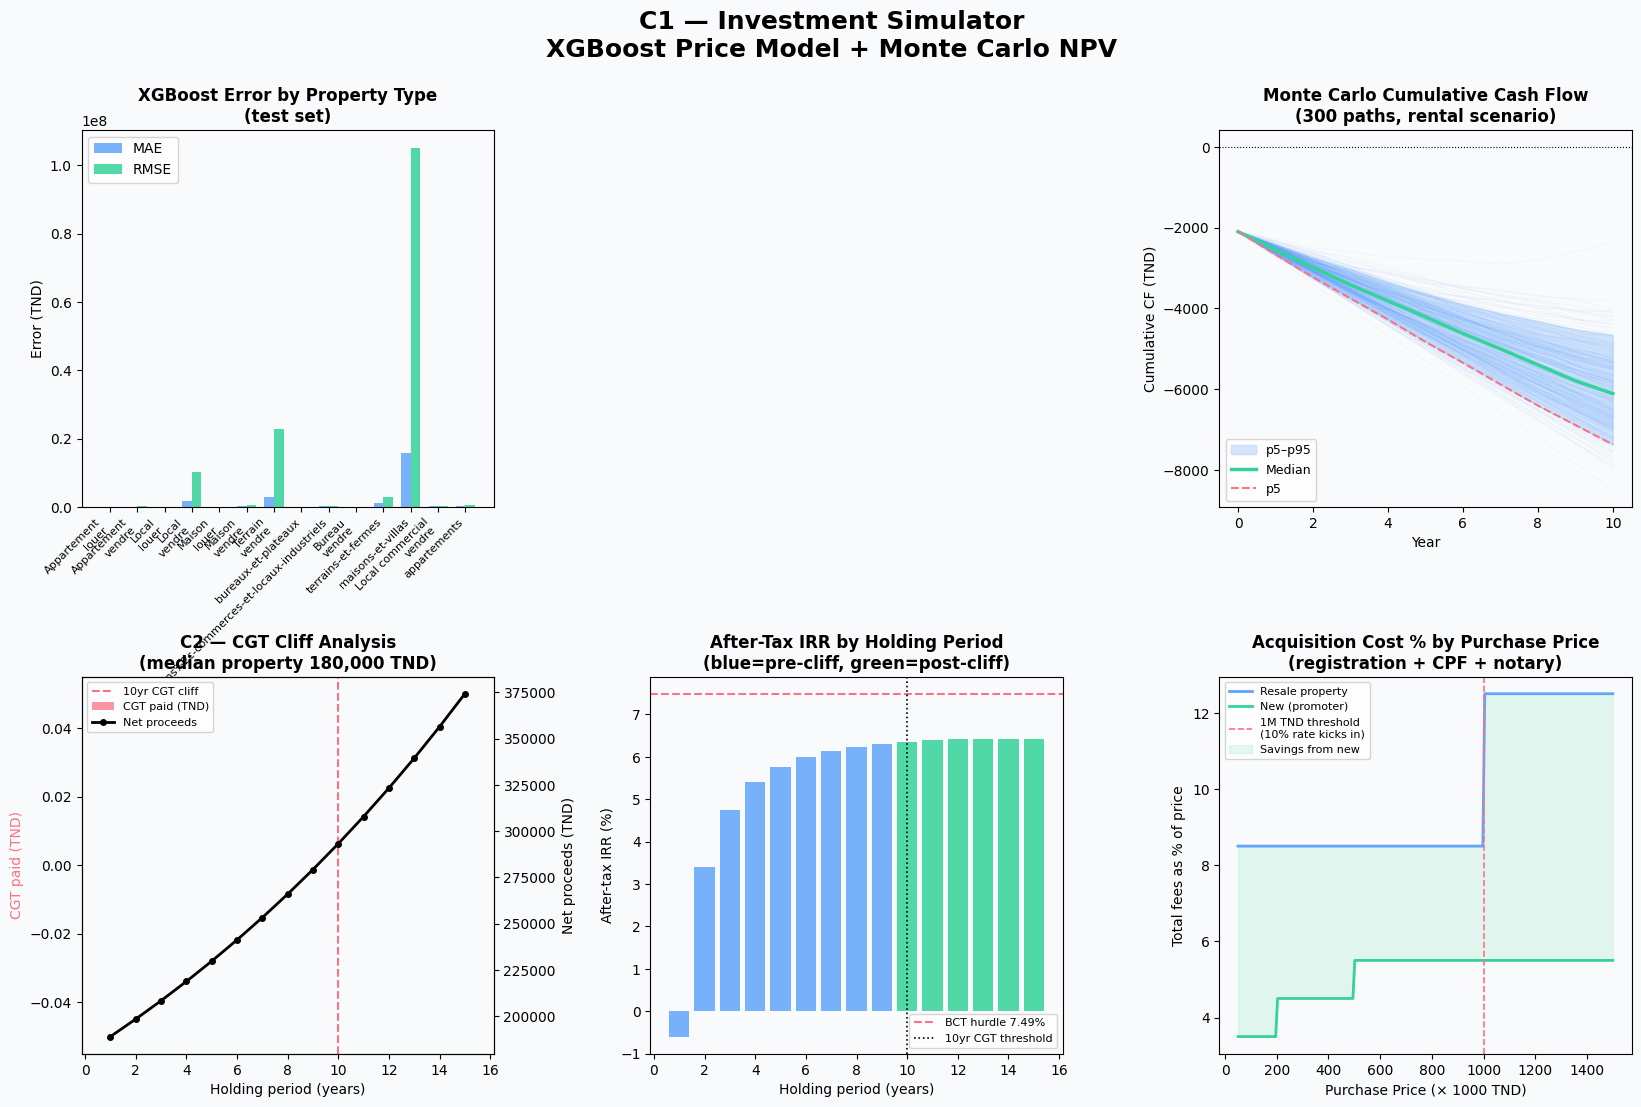

Saved: viz_02_c1_c2_models.png


In [60]:
import matplotlib.pyplot as plt

ACCENT  = "#60A5FA" # Blue
ACCENT2 = "#34D399" # Green
WARN    = "#FB7185" # Red
NEUTRAL = "#9CA3AF" # Gray
BG      = "#F9FAFB" # Light Gray

# ════════════════════════════════════════════════════════════════
# VIZ CELL 2 — C1 XGBoost model performance + Monte Carlo NPV
# ════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 12), facecolor=BG)
fig.suptitle("C1 — Investment Simulator\nXGBoost Price Model + Monte Carlo NPV",
             fontsize=18, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# ══ 1. XGBoost MAE per type ════════════════════
ax1 = fig.add_subplot(gs[0, 0])
if hasattr(generator.simulator, '_xgb_models') and generator.simulator._xgb_models:
    types   = list(generator.simulator._xgb_models.keys())
    maes    = [generator.simulator._xgb_models[t]["mae"]  for t in types]
    rmses   = [generator.simulator._xgb_models[t]["rmse"] for t in types]
    x       = np.arange(len(types))
    w       = 0.35
    ax1.bar(x - w/2, maes,  w, label="MAE",  color=ACCENT,  alpha=0.85)
    ax1.bar(x + w/2, rmses, w, label="RMSE", color=ACCENT2, alpha=0.85)
    ax1.set_xticks(x)
    ax1.set_xticklabels([t.replace(" a ","\n") for t in types],
                         rotation=45, ha="right", fontsize=8)
    ax1.set_title("XGBoost Error by Property Type\n(test set)", fontweight="bold")
    ax1.set_ylabel("Error (TND)")
    ax1.legend()
else:
    ax1.text(0.5, 0.5, "Run generator to populate\nXGBoost models",
             ha="center", va="center", transform=ax1.transAxes, color=NEUTRAL)
    ax1.set_title("XGBoost MAE / RMSE", fontweight="bold")
ax1.set_facecolor(BG)

# ══ 3. Monte Carlo NPV fan chart for a sample property ════════════
ax3 = fig.add_subplot(gs[0, 2])
sample_prop = df_modeling[df_modeling["price_numeric"].notna()].sample(
    1, random_state=7).iloc[0].to_dict()
C     = TUNISIA_CONSTANTS
price = float(sample_prop["price_numeric"])
down  = price * (1 - C["ltv_max"])
rng   = np.random.default_rng(42)
years = 10
n_fan = 300   # paths to draw (visual only — lighter than full 10k)
appr_s  = rng.normal(C["appreciation_national"], 0.02, (n_fan, years))
gy_s    = rng.normal(C["gross_yield_national"],  0.015, n_fan).clip(0.01, 0.15)
vac_s   = rng.beta(2, 8, (n_fan, years))
cum_npv = np.zeros((n_fan, years+1))
for s in range(n_fan):
    cur = price
    cf  = [-down]
    for yr in range(years):
        cur  *= (1 + appr_s[s, yr])
        nr    = cur * gy_s[s] * (1 - vac_s[s, yr]) * (1 - C["irpp_rental_flat"])
        cf.append(nr - cur*0.01 - price*(C["mortgage_rate_mid"]/12)*12)
    cum = np.cumsum(cf)
    cum_npv[s] = cum
for s in range(n_fan):
    ax3.plot(range(years+1), cum_npv[s], alpha=0.06, linewidth=0.7,
             color=ACCENT)
p5  = np.percentile(cum_npv, 5,  axis=0)
p50 = np.percentile(cum_npv, 50, axis=0)
p95 = np.percentile(cum_npv, 95, axis=0)
ax3.fill_between(range(years+1), p5, p95, alpha=0.25, color=ACCENT, label="p5–p95")
ax3.plot(range(years+1), p50, color=ACCENT2, linewidth=2.5, label="Median")
ax3.plot(range(years+1), p5,  color=WARN,   linewidth=1.5, linestyle="--", label="p5")
ax3.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax3.set_title("Monte Carlo Cumulative Cash Flow\n(300 paths, rental scenario)",
              fontweight="bold")
ax3.set_xlabel("Year")
ax3.set_ylabel("Cumulative CF (TND)")
ax3.legend(fontsize=9)
ax3.set_facecolor(BG)

# ══ 4. C2 — CGT cliff visualisation ═══════════════════
ax4 = fig.add_subplot(gs[1, 0])
sample_price = float(df_modeling["price_numeric"].median())
hold_years   = list(range(1, 16))
cgt_taxes, net_proceeds_list, irrs = [], [], []
for yr in hold_years:
    info = generator.tax_optimizer.compute_capital_gains_tax(
        sample_price,
        sample_price * (1 + C["appreciation_national"]) ** yr,
        yr)
    cgt_taxes.append(info["cgt"])
    net_proceeds_list.append(info["net_proceeds"])
ax4_twin = ax4.twinx()
ax4.bar(hold_years, cgt_taxes, color=[WARN if y < 10 else ACCENT2 for y in hold_years],
        alpha=0.75, label="CGT paid (TND)")
ax4_twin.plot(hold_years, net_proceeds_list, color="black", linewidth=2,
              marker="o", markersize=4, label="Net proceeds")
ax4.axvline(10, color=WARN, linestyle="--", linewidth=1.5,
            label="10yr CGT cliff")
ax4.set_title(f"C2 — CGT Cliff Analysis\n(median property {sample_price:,.0f} TND)",
              fontweight="bold")
ax4.set_xlabel("Holding period (years)")
ax4.set_ylabel("CGT paid (TND)", color=WARN)
ax4_twin.set_ylabel("Net proceeds (TND)")
lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1+lines2, labels1+labels2, fontsize=8, loc="upper left")
ax4.set_facecolor(BG)

# ══ 5. Holding period IRR sweep ════════════════════
ax5 = fig.add_subplot(gs[1, 1])
sample_pd = df_modeling[df_modeling["price_numeric"].notna()].sample(
    1, random_state=99).iloc[0].to_dict()
sweep = generator.tax_optimizer.sweep_holding_period(
    sample_pd, {"is_new_promoter": False})
yrs_sw  = [r["years"]   for r in sweep]
irr_sw  = [r["irr_pct"] for r in sweep]
colors_s= [ACCENT2 if i >= 10 else ACCENT for i in yrs_sw]
ax5.bar(yrs_sw, irr_sw, color=colors_s, alpha=0.85)
ax5.axhline(C["bcт_tmm"]*100, color=WARN, linestyle="--", linewidth=1.5,
            label=f"BCT hurdle {C['bcт_tmm']*100:.2f}%")
ax5.axvline(10, color="black", linestyle=":", linewidth=1.2,
            label="10yr CGT threshold")
ax5.set_title("After-Tax IRR by Holding Period\n(blue=pre-cliff, green=post-cliff)",
              fontweight="bold")
ax5.set_xlabel("Holding period (years)")
ax5.set_ylabel("After-tax IRR (%)")
ax5.legend(fontsize=8)
ax5.set_facecolor(BG)

# ══ 6. Acquisition cost breakdown ══════════════════
ax6 = fig.add_subplot(gs[1, 2])
price_range = np.linspace(50_000, 1_500_000, 200)
fees_resale  = [generator.tax_optimizer.compute_acquisition_costs(p)["fees_pct"]
                for p in price_range]
fees_new     = [generator.tax_optimizer.compute_acquisition_costs(p, True)["fees_pct"]
                for p in price_range]
ax6.plot(price_range/1000, fees_resale, color=ACCENT,  linewidth=2,
         label="Resale property")
ax6.plot(price_range/1000, fees_new,    color=ACCENT2, linewidth=2,
         label="New (promoter)")
ax6.axvline(1000, color=WARN, linestyle="--", linewidth=1.2,
            label="1M TND threshold\n(10% rate kicks in)")
ax6.fill_between(price_range/1000, fees_new, fees_resale,
                 alpha=0.12, color=ACCENT2, label="Savings from new")
ax6.set_title("Acquisition Cost % by Purchase Price\n(registration + CPF + notary)",
              fontweight="bold")
ax6.set_xlabel("Purchase Price (× 1000 TND)")
ax6.set_ylabel("Total fees as % of price")
ax6.legend(fontsize=8)
ax6.set_facecolor(BG)

plt.savefig("viz_02_c1_c2_models.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Saved: viz_02_c1_c2_models.png")

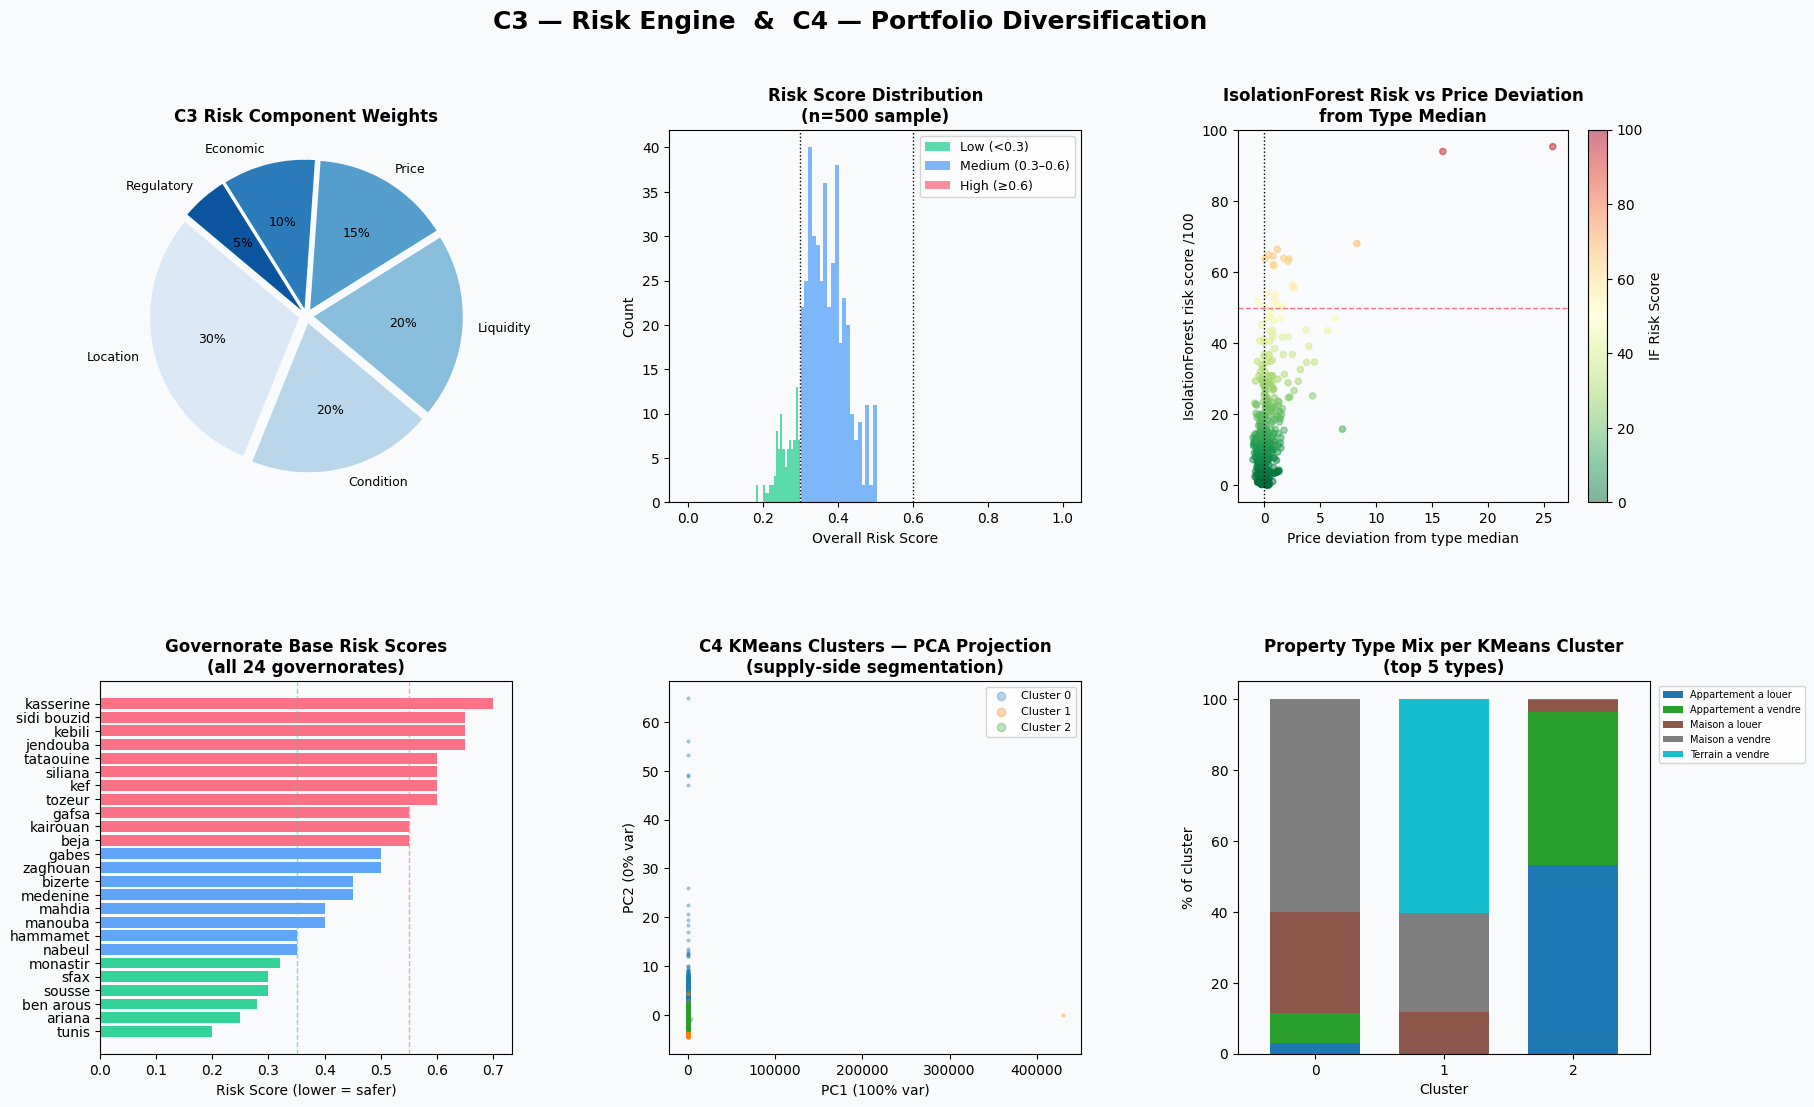

Saved: viz_03_c3_c4_models.png


In [62]:
import matplotlib.pyplot as plt

ACCENT  = "#60A5FA" # Blue
ACCENT2 = "#34D399" # Green
WARN    = "#FB7185" # Red
NEUTRAL = "#9CA3AF" # Gray
BG      = "#F9FAFB" # Light Gray

# ═══════════════════════════════════════════════════════════════════════════
# VIZ CELL 3 — C3 Risk Engine breakdown + C4 Portfolio clustering
# ═══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 12), facecolor=BG)
fig.suptitle("C3 — Risk Engine  &  C4 — Portfolio Diversification",
             fontsize=18, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.38)

# ── 1. Risk component weights (pie) ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
weights = generator.risk_engine.WEIGHTS
labels  = [k.replace("_risk","").replace("_"," ").title() for k in weights]
vals    = list(weights.values())
explode = [0.05]*len(vals)
wedge_colors = sns.color_palette("Blues", len(vals))
ax1.pie(vals, labels=labels, autopct="%1.0f%%", colors=wedge_colors,
        explode=explode, startangle=140, textprops={"fontsize":9})
ax1.set_title("C3 Risk Component Weights", fontweight="bold")

# ── 2. Risk score distribution across dataset ─────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
sample_n = min(500, len(df_modeling))
sample_df = df_modeling[df_modeling["price_numeric"].notna()].sample(
    sample_n, random_state=42)
risk_scores = [generator.risk_engine.calculate_overall_risk(
                   row.to_dict())["overall_risk_score"]
               for _, row in sample_df.iterrows()]
risk_arr = np.array(risk_scores)
ax2.hist(risk_arr[risk_arr < 0.3],  bins=20, color=ACCENT2, alpha=0.8, label="Low (<0.3)")
ax2.hist(risk_arr[(risk_arr>=0.3) & (risk_arr<0.6)],
         bins=20, color=ACCENT,  alpha=0.8, label="Medium (0.3–0.6)")
ax2.hist(risk_arr[risk_arr>=0.6],   bins=20, color=WARN,   alpha=0.8, label="High (≥0.6)")
ax2.axvline(0.3, color="black", linestyle=":", linewidth=1)
ax2.axvline(0.6, color="black", linestyle=":", linewidth=1)
ax2.set_title(f"Risk Score Distribution\n(n={sample_n} sample)", fontweight="bold")
ax2.set_xlabel("Overall Risk Score")
ax2.set_ylabel("Count")
ax2.legend(fontsize=9)
ax2.set_facecolor(BG)

# ── 3. IsolationForest score vs price deviation ───────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
if_scores_list, price_devs = [], []
for _, row in sample_df.iterrows():
    pd_   = row.to_dict()
    typ   = pd_.get("Type","")
    peers = df_modeling[df_modeling["Type"]==typ]["price_numeric"].median()
    if peers and peers > 0:
        dev = (float(pd_.get("price_numeric",0) or 0) - peers) / peers
        price_devs.append(dev)
        if_scores_list.append(generator.risk_engine._if_score(pd_))
if price_devs:
    sc = ax3.scatter(price_devs, if_scores_list,
                     c=if_scores_list, cmap="RdYlGn_r",
                     alpha=0.5, s=20, vmin=0, vmax=100)
    plt.colorbar(sc, ax=ax3, label="IF Risk Score")
    ax3.axvline(0,    color="black", linestyle=":", linewidth=1)
    ax3.axhline(50,   color=WARN,    linestyle="--", linewidth=1)
    ax3.set_title("IsolationForest Risk vs Price Deviation\nfrom Type Median",
                  fontweight="bold")
    ax3.set_xlabel("Price deviation from type median")
    ax3.set_ylabel("IsolationForest risk score /100")
ax3.set_facecolor(BG)

# ── 4. Governorate risk table heatmap ─────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
gov_risk = generator.risk_engine.GOV_RISK
gov_df   = pd.DataFrame(list(gov_risk.items()),
                         columns=["Governorate","Risk"]).sort_values("Risk")
bar_colors = [ACCENT2 if v < 0.35 else ACCENT if v < 0.55 else WARN
              for v in gov_df["Risk"]]
ax4.barh(gov_df["Governorate"], gov_df["Risk"], color=bar_colors)
ax4.axvline(0.35, color=ACCENT2, linestyle="--", linewidth=1, alpha=0.6)
ax4.axvline(0.55, color=WARN,    linestyle="--", linewidth=1, alpha=0.6)
ax4.set_title("Governorate Base Risk Scores\n(all 24 governorates)",
              fontweight="bold")
ax4.set_xlabel("Risk Score (lower = safer)")
ax4.set_facecolor(BG)

# ── 5. KMeans cluster visualisation (PCA 2D projection) ───────────────────
ax5 = fig.add_subplot(gs[1, 1])
from sklearn.decomposition import PCA
if (hasattr(generator.portfolio_advisor, "_kmeans_model") and
        generator.portfolio_advisor._kmeans_model is not None):
    feat_cols = generator.portfolio_advisor._cluster_feats
    X_raw = df_modeling[feat_cols].astype(float).fillna(0)
    X_sc  = generator.portfolio_advisor._kmeans_scaler.transform(X_raw)
    pca   = PCA(n_components=2, random_state=42)
    X_2d  = pca.fit_transform(X_sc)
    labels_km = generator.portfolio_advisor._clusters_kmeans
    palette   = sns.color_palette("tab10", len(set(labels_km)))
    for cl in sorted(set(labels_km)):
        mask = labels_km == cl
        ax5.scatter(X_2d[mask, 0], X_2d[mask, 1],
                    s=4, alpha=0.3, color=palette[cl],
                    label=f"Cluster {cl}", rasterized=True)
    ax5.set_title("C4 KMeans Clusters — PCA Projection\n(supply-side segmentation)",
                  fontweight="bold")
    ax5.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% var)")
    ax5.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% var)")
    ax5.legend(markerscale=3, fontsize=8)
else:
    ax5.text(0.5, 0.5, "Run generator to build\nKMeans clusters",
             ha="center", va="center", transform=ax5.transAxes, color=NEUTRAL)
    ax5.set_title("KMeans Clusters — PCA Projection", fontweight="bold")
ax5.set_facecolor(BG)

# ── 6. Cluster composition — type breakdown per cluster ───────────────────
ax6 = fig.add_subplot(gs[1, 2])
if (hasattr(generator.portfolio_advisor, "_clusters_kmeans") and
        generator.portfolio_advisor._clusters_kmeans is not None):
    df_cl = df_modeling.copy()
    df_cl["_cluster"] = generator.portfolio_advisor._clusters_kmeans
    top_types = df_modeling["Type"].value_counts().head(5).index
    df_cl_top = df_cl[df_cl["Type"].isin(top_types)]
    ct = (df_cl_top.groupby(["_cluster","Type"])
          .size().unstack(fill_value=0))
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind="bar", ax=ax6, stacked=True,
                colormap="tab10", width=0.7)
    ax6.set_title("Property Type Mix per KMeans Cluster\n(top 5 types)",
                  fontweight="bold")
    ax6.set_xlabel("Cluster")
    ax6.set_ylabel("% of cluster")
    ax6.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
    ax6.tick_params(axis="x", rotation=0)
else:
    ax6.text(0.5, 0.5, "No cluster data", ha="center", va="center",
             transform=ax6.transAxes, color=NEUTRAL)
    ax6.set_title("Type Mix per Cluster", fontweight="bold")
ax6.set_facecolor(BG)

plt.savefig("viz_03_c3_c4_models.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Saved: viz_03_c3_c4_models.png")

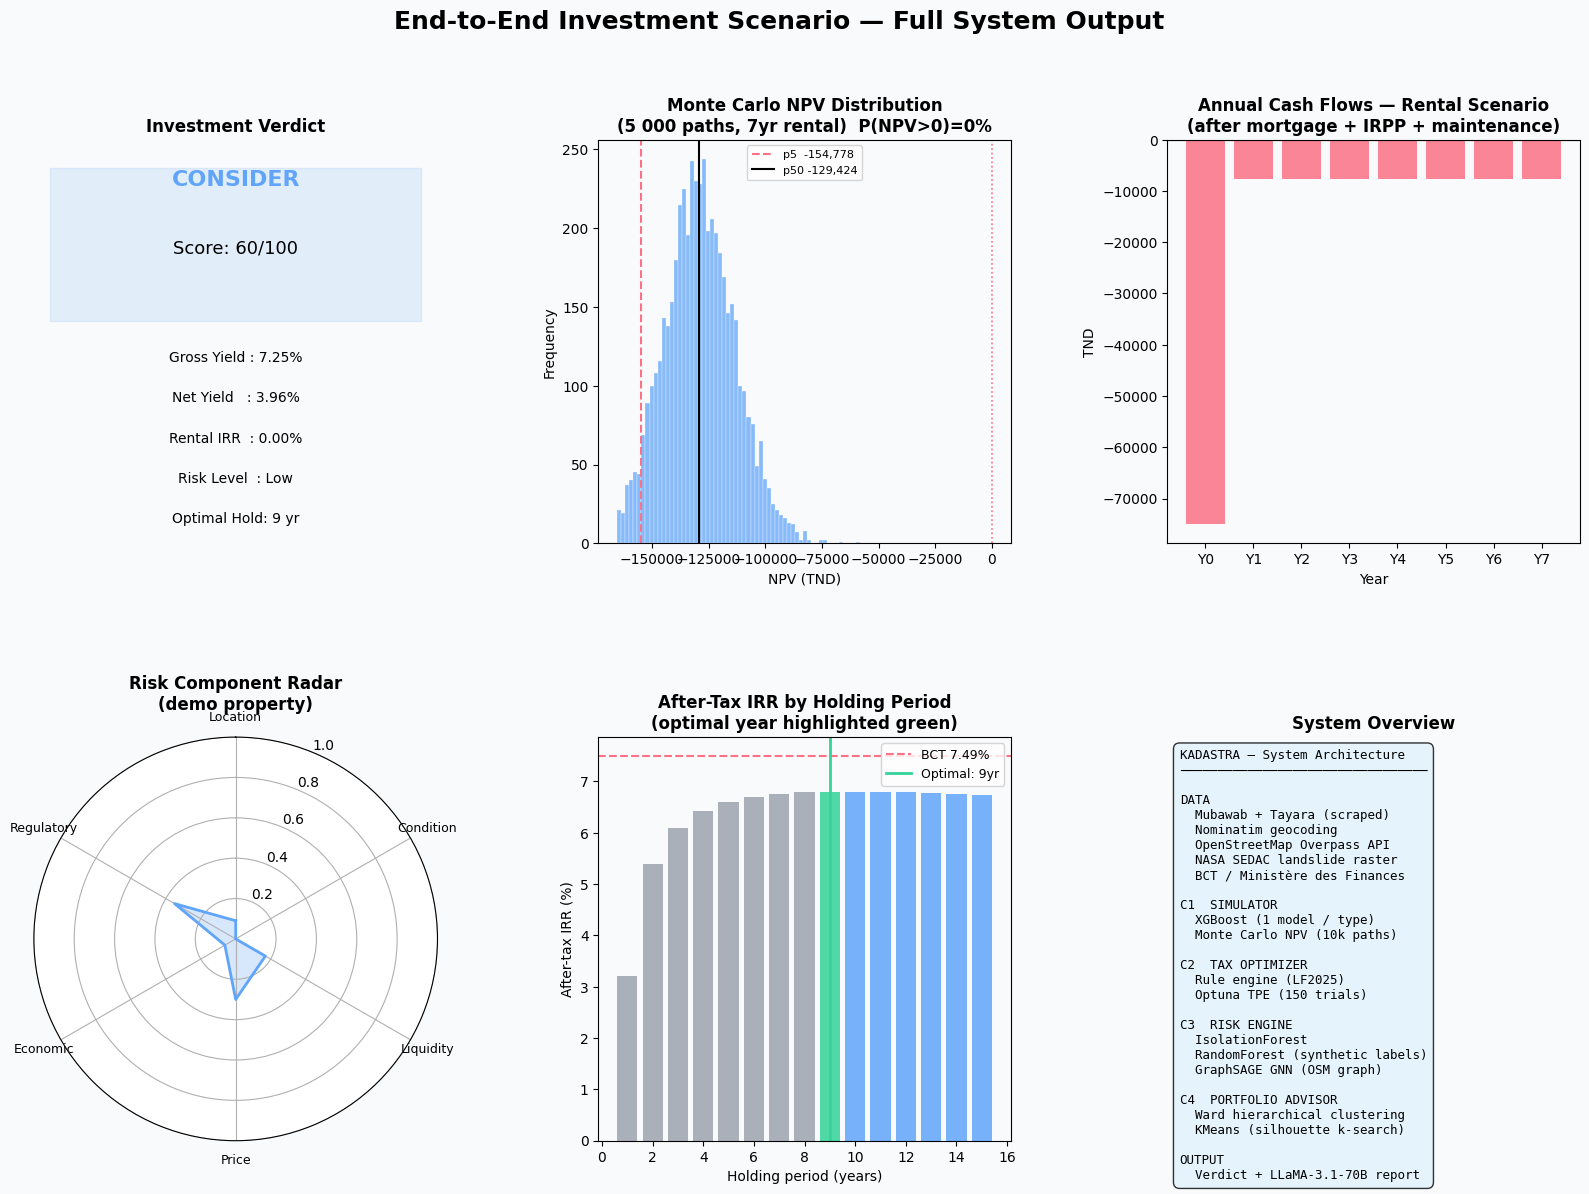

Saved: viz_04_full_scenario.png


In [63]:
# ═══════════════════════════════════════════════════════════════════════════
# VIZ CELL 4 — Full system: end-to-end scenario for one property
# ═══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 13), facecolor=BG)
fig.suptitle("End-to-End Investment Scenario — Full System Output",
             fontsize=18, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.38)

# Run one scenario on the manual example property
demo_prop = {
    'Type':            'Appartement a vendre',
    'Adresse':         'Tunis, Les Berges du Lac',
    'price_numeric':   250_000,
    'surface_numeric': 120,
    'neuf': 1, 'parking': 1, 'balcon_terrasse': 1,
    'climatisation': 1, 'chauffage': 1, 'ascenseur': 1,
}
demo_profile = {
    'budget': 300_000, 'holding_period_years': 7,
    'rental_income': 0,       # will be auto-filled from C1
    'first_time_buyer':     True,
    'is_new_promoter':      True,
    'risk_tolerance':       'medium',
}
sc = generator.generate_investment_scenario(demo_prop, demo_profile)

# ── 1. Verdict scorecard ───────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1); ax1.axis("off")
score   = sc["verdict"]["score"]
rec     = sc["verdict"]["recommendation"]
col_rec = (ACCENT2 if "BUY" in rec else
           ACCENT   if "CONSIDER" in rec else
           WARN)
ax1.add_patch(plt.Rectangle((0.05,0.55), 0.9, 0.38,
              color=col_rec, alpha=0.15, transform=ax1.transAxes))
ax1.text(0.5, 0.90, rec, ha="center", va="center", fontsize=16,
         fontweight="bold", color=col_rec, transform=ax1.transAxes)
ax1.text(0.5, 0.72, f"Score: {score}/100", ha="center", fontsize=13,
         transform=ax1.transAxes)
ax1.text(0.5, 0.45, f"Gross Yield : {sc['simulator']['rental_yield']['gross_yield']:.2f}%",
         ha="center", fontsize=10, transform=ax1.transAxes)
ax1.text(0.5, 0.35, f"Net Yield   : {sc['simulator']['rental_yield']['net_yield']:.2f}%",
         ha="center", fontsize=10, transform=ax1.transAxes)
ax1.text(0.5, 0.25, f"Rental IRR  : {sc['simulator']['roi_rental']['irr_percent']:.2f}%",
         ha="center", fontsize=10, transform=ax1.transAxes)
ax1.text(0.5, 0.15, f"Risk Level  : {sc['risk']['risk_level']}",
         ha="center", fontsize=10, transform=ax1.transAxes)
ax1.text(0.5, 0.05, f"Optimal Hold: {sc['tax']['optimal_holding_years']} yr",
         ha="center", fontsize=10, transform=ax1.transAxes)
ax1.set_title("Investment Verdict", fontweight="bold")

# ── 2. Monte Carlo NPV distribution (histogram) ───────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
mc_full = generator.simulator.monte_carlo_npv(demo_prop, years=7, n_sims=5000)
rng2    = np.random.default_rng(42)
appr_f  = rng2.normal(C["appreciation_national"], 0.02, (5000, 7))
gy_f    = rng2.normal(C["gross_yield_national"],  0.015, 5000).clip(0.01, 0.15)
vac_f   = rng2.beta(2, 8, (5000, 7))
price_d = 250_000; down_d = price_d*(1-C["ltv_max"])
mrate   = C["mortgage_rate_mid"]/12; nmo = C["mortgage_max_years"]*12
mpmt    = float(np.abs(np.pmt(mrate, nmo, price_d-down_d))) if hasattr(np,'pmt') else 0
try:
    import numpy_financial as npf2
    mpmt = float(npf2.pmt(mrate, nmo, -(price_d-down_d)))
except Exception:
    mpmt = price_d * 0.007
npvs_d = []
for s in range(5000):
    cur = price_d; cf = [-down_d]
    for yr in range(7):
        cur *= (1+appr_f[s,yr])
        nr   = cur*gy_f[s]*(1-vac_f[s,yr])*(1-C["irpp_rental_flat"])
        cf.append(nr - cur*0.01 - mpmt*12)
    try:
        npvs_d.append(float(__import__("numpy_financial").npv(C["bcт_tmm"], cf)))
    except Exception:
        npvs_d.append(sum(c/(1+C["bcт_tmm"])**i for i,c in enumerate(cf)))
npvs_arr = np.array(npvs_d)
p_pos    = (npvs_arr > 0).mean()
ax2.hist(npvs_arr[npvs_arr > np.percentile(npvs_arr,1)], bins=60,
         color=ACCENT, alpha=0.75, edgecolor="white", linewidth=0.3)
ax2.axvline(np.percentile(npvs_arr,5),  color=WARN,   linestyle="--",
            linewidth=1.5, label=f"p5  {np.percentile(npvs_arr,5):,.0f}")
ax2.axvline(np.percentile(npvs_arr,50), color="black",linestyle="-",
            linewidth=1.5, label=f"p50 {np.percentile(npvs_arr,50):,.0f}")
ax2.axvline(0, color=WARN, linestyle=":", linewidth=1.2)
ax2.set_title(f"Monte Carlo NPV Distribution\n(5 000 paths, 7yr rental)  "
              f"P(NPV>0)={p_pos*100:.0f}%", fontweight="bold")
ax2.set_xlabel("NPV (TND)")
ax2.set_ylabel("Frequency")
ax2.legend(fontsize=8)
ax2.set_facecolor(BG)

# ── 3. Annual cash flow waterfall ─────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
cfs = sc["simulator"]["roi_rental"]["cash_flows"]
colors_cf = [ACCENT2 if v >= 0 else WARN for v in cfs]
labels_cf = ["Y0"] + [f"Y{i}" for i in range(1, len(cfs))]
ax3.bar(labels_cf, cfs, color=colors_cf, alpha=0.85)
ax3.axhline(0, color="black", linewidth=0.8)
ax3.set_title("Annual Cash Flows — Rental Scenario\n(after mortgage + IRPP + maintenance)",
              fontweight="bold")
ax3.set_xlabel("Year")
ax3.set_ylabel("TND")
ax3.set_facecolor(BG)

# ── 4. Risk component radar chart ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0], polar=True)
comp   = sc["risk"]["component_scores"]
labels_r = [k.replace("_risk","\
").replace("_","\
").title() for k in comp]
vals_r   = list(comp.values())
vals_r  += vals_r[:1]   # close the polygon
angles   = np.linspace(0, 2*np.pi, len(labels_r), endpoint=False).tolist()
angles  += angles[:1]
ax4.set_theta_offset(np.pi/2)
ax4.set_theta_direction(-1)
ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(labels_r, fontsize=9)
ax4.set_ylim(0, 1)
ax4.plot(angles, vals_r, color=ACCENT, linewidth=2)
ax4.fill(angles, vals_r, color=ACCENT, alpha=0.25)
ax4.set_title("Risk Component Radar\n(demo property)", fontweight="bold", pad=20)

# ── 5. Holding period sweep with optimum highlighted ──────────────────────
ax5 = fig.add_subplot(gs[1, 1])
sweep = sc["tax"]["holding_period_sweep"]
yrs_  = [r["years"]   for r in sweep]
irrs_ = [r["irr_pct"] for r in sweep]
opt_y = sc["tax"]["optimal_holding_years"]
bar_c = [ACCENT2 if y == opt_y else (ACCENT if y >= 10 else NEUTRAL)
         for y in yrs_]
ax5.bar(yrs_, irrs_, color=bar_c, alpha=0.85)
ax5.axhline(C["bcт_tmm"]*100, color=WARN, linestyle="--",
            linewidth=1.5, label=f"BCT {C['bcт_tmm']*100:.2f}%")
ax5.axvline(opt_y, color=ACCENT2, linestyle="-", linewidth=2,
            label=f"Optimal: {opt_y}yr")
ax5.set_title("After-Tax IRR by Holding Period\n(optimal year highlighted green)",
              fontweight="bold")
ax5.set_xlabel("Holding period (years)")
ax5.set_ylabel("After-tax IRR (%)")
ax5.legend(fontsize=9)
ax5.set_facecolor(BG)

# ── 6. System architecture summary ────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis("off")
arch_text = (
    "KADASTRA — System Architecture\n"
    "─────────────────────────────────\n\n"
    "DATA\n"
    "  Mubawab + Tayara (scraped)\n"
    "  Nominatim geocoding\n"
    "  OpenStreetMap Overpass API\n"
    "  NASA SEDAC landslide raster\n"
    "  BCT / Ministère des Finances\n\n"
    "C1  SIMULATOR\n"
    "  XGBoost (1 model / type)\n"
    "  Monte Carlo NPV (10k paths)\n\n"
    "C2  TAX OPTIMIZER\n"
    "  Rule engine (LF2025)\n"
    "  Optuna TPE (150 trials)\n\n"
    "C3  RISK ENGINE\n"
    "  IsolationForest\n"
    "  RandomForest (synthetic labels)\n"
    "  GraphSAGE GNN (OSM graph)\n\n"
    "C4  PORTFOLIO ADVISOR\n"
    "  Ward hierarchical clustering\n"
    "  KMeans (silhouette k-search)\n\n"
    "OUTPUT\n"
    "  Verdict + LLaMA-3.1-70B report"
)
ax6.text(0.03, 0.97, arch_text, transform=ax6.transAxes,
         fontsize=9, verticalalignment="top",
         fontfamily="monospace",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#E0F2FE", alpha=0.8))
ax6.set_title("System Overview", fontweight="bold")

plt.savefig("viz_04_full_scenario.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Saved: viz_04_full_scenario.png")

# Download all plots
try:
    from google.colab import files
    for fname in ["viz_01_dataset_overview.png","viz_02_c1_c2_models.png",
                  "viz_03_c3_c4_models.png","viz_04_full_scenario.png"]:
        files.download(fname)
except Exception:
    pass